# Multilevel Regression and Poststratification (MRP) in PyMC

On many occasions, I read about Multilevel Regression and Poststratification (MRP) in the context of survey analysis (see for example [Multilevel Regression and Post-stratification in Bambi](https://bambinos.github.io/bambi/notebooks/mister_p.html)). It kind of makes sense, because the method is used to combine survey data with a census, and survey data is often biased. However, it was unclear for me how the results of the MRP model depended on the type of census used. In particular, I was unsure about the requirements on the census data and its relation to the target variable. In this notebook, I finally explore this method in detail, following the advice of the [Bayesian Workflow](https://avehtari.github.io/Bayesian-Workflow/) book: explicitly generating synthetic data, fitting the model, checking parameter recovery and trying to break the method. In addition, I describe how the MRP method is related to the g-formula of causal inference (a connection I found while discussing this with Claude). I also express the poststratification step in the language of marginal effects, using the `datagrid` function of the [marginaleffects](https://marginaleffects.com/) package.

### Motivation

A survey rarely looks like the population it is supposed to describe. Young people answer online polls more often than old people, and loyal customers answer satisfaction surveys more often than unhappy ones. If we take the sample mean, we measure the sample, not the population. Multilevel Regression and Poststratification (MRP) is a two-step method to get from one to the other.

### The Method (tl;dr)

The idea is to split the question in two.

- First, we ask what each *type* of person answers: we fit a model that predicts the outcome from demographics and geography. Many cells of this cross-classification have few respondents or none, so we fit the model hierarchically and let small cells borrow strength from the rest.

- Second, we ask how many people of each type there are in the population. We take these counts from a census and average the model predictions with the counts as weights. The survey informs the first step and the census informs the second.

### Simulated Example

The canonical demonstration of MRP is the 2012 Xbox poll ([Wang, Rothschild, Goel and Gelman, 2015](https://sites.stat.columbia.edu/gelman/research/published/forecasting-with-nonrepresentative-polls.pdf)). The respondents were mostly young men, and the poststratified estimates still tracked the election results at the state level. This motivates our synthetic example: we simulate a population and a survey. We model a simple binary variable ("yes" or "no"), indicating the preference for a candidate. We also simulate covariates: age group, ethnicity and state of residence. For each state of residence, we simulate the vote share of a candidate in the previous election. We then generate the survey data by drawing respondents from the population, with a probability that depends on the cell they are in, that is, the stratum defined by state, age group and ethnicity.


## Prepare Notebook

In [1]:
import itertools

import arviz as az
import graphviz as gr
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
import pymc as pm
import pymc.dims as pmd
import xarray as xr
from marginaleffects import datagrid

seed: int = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)

HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

## The Problem and the Estimand

Consider a population of $N$ people. We want to know the share of them that would answer "yes" to a question, for example whether they support a candidate. We describe each person by a small set of discrete covariates $X$, here age group, ethnicity and state of residence. The cross-classification of these covariates partitions the population into $J$ cells. Cell $j$ contains $N_j$ people, so $\sum_{j=1}^{J} N_j = N$. We know the counts $N_j$ from a census.

Let $y \in \{0, 1\}$ be the answer of a person. The mean answer inside cell $j$ is

$$\theta_j = \text{E}[y \mid X = x_j],$$

where $x_j$ denotes the covariate values that define cell $j$. The quantity we want, the population share, is the count-weighted average of the cell means:

$$\theta = \frac{\sum_{j=1}^{J} N_j \, \theta_j}{\sum_{j=1}^{J} N_j}.$$

We never observe the whole population. We observe a survey with $n$ respondents, with $n_j$ of them in cell $j$ and $y_j$ of those answering "yes". The problem is that the probability to respond depends on the cell. In our example young people respond much more often than old people, so the sample has too many young respondents.

The sample mean is

$$\bar{y} = \frac{\sum_{j=1}^{J} y_j}{n} = \sum_{j : n_j > 0} \frac{n_j}{n} \, \frac{y_j}{n_j},$$

which weights the observed cell means $y_j / n_j$ by the *sample* shares $n_j / n$. The target $\theta$ weights the cell means by the *population* shares $N_j / N$. When the two sets of shares differ, $\bar{y}$ is biased, and more respondents do not help.

The fix follows from the two formulas. We need an estimate of every cell mean $\theta_j$, also for cells with $n_j$ close to zero, and then we need to average those estimates with the known weights $N_j / N$. MRP does exactly this: the *multilevel regression* provides the $\theta_j$, and the *poststratification* provides the average. The survey tells us how each type of person answers. The census tells us how many people of each type there are.

## The MRP Assumption as a Causal DAG

When is it valid to combine the survey and the census in this way? We answer with a causal DAG. Let $I \in \{0, 1\}$ be the response indicator: $I = 1$ if the person is in the survey. All our data is conditional on $I = 1$. We draw a conditioned node as a box.

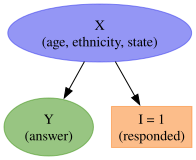

In [2]:
dag = gr.Digraph()

dag.node("X", label="X\n(age, ethnicity, state)", color="#2a2eec80", style="filled")
dag.node("Y", label="Y\n(answer)", color="#328c0680", style="filled")
dag.node(
    "I", label="I = 1\n(responded)", shape="box", color="#fa7c1780", style="filled"
)

dag.edge("X", "I")
dag.edge("X", "Y")

dag

In this graph $X$ is a common cause of the response and of the answer. Once $X$ is in the model, conditioning on $I = 1$ opens no path into $Y$, because $X$ blocks the only route. The assumption is

$$Y \perp I \mid X,$$

together with a positivity condition: every cell with $N_j > 0$ must have a positive probability to be observed, $\text{P}(I = 1 \mid X = x_j) > 0$. Under these two conditions the response mechanism can depend on $X$ as strongly as it wants. An unrepresentative sample is not the problem. A sample that is unrepresentative *in ways not captured by $X$* is the problem. There are two ways this happens.

### Failure mode 1: the answer drives the response

People who would answer "yes" respond more often than people who would answer "no". The arrow $Y \to I$ creates a dependence between $Y$ and $I$ inside every cell. No poststratification frame can fix this, because the bias lives within the cells. This is non-ignorable non-response, and it needs a model of the response mechanism, not a bigger census table.

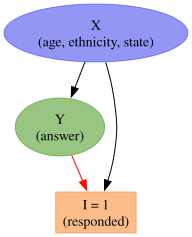

In [3]:
dag = gr.Digraph()

dag.node("X", label="X\n(age, ethnicity, state)", color="#2a2eec80", style="filled")
dag.node("Y", label="Y\n(answer)", color="#328c0680", style="filled")
dag.node(
    "I", label="I = 1\n(responded)", shape="box", color="#fa7c1780", style="filled"
)

dag.edge("X", "I")
dag.edge("X", "Y")
dag.edge("Y", "I", color="red")

dag

In the simulation below, we will see how we can break the MRP model when this failure mode is present.

### Failure mode 2: an unmeasured common cause

A variable $U$ that we did not measure, such as political interest, drives both the response and the answer. Inside a cell defined by $X$, the path $I \leftarrow U \to Y$ is open, so $Y \not\perp I \mid X$. The fix is to measure $U$ and to add it to the model *and* to the frame. This promotes $U$ into $X$ and brings us back to the first graph.

The last sentence has a practical consequence. We can only poststratify over variables that appear in both the model and the census. A predictor that is not in the frame gives cells we cannot count. A frame variable that is not in the model is pooled implicitly, and its selection bias survives. The frame therefore constrains the regression before we write a single prior. In a real project, the frame comes first.

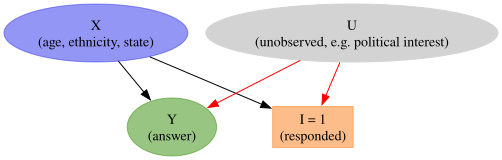

In [4]:
dag = gr.Digraph()

dag.node("X", label="X\n(age, ethnicity, state)", color="#2a2eec80", style="filled")
dag.node("Y", label="Y\n(answer)", color="#328c0680", style="filled")
dag.node(
    "I", label="I = 1\n(responded)", shape="box", color="#fa7c1780", style="filled"
)
dag.node(
    "U",
    label="U\n(unobserved, e.g. political interest)",
    color="lightgray",
    style="filled",
)

dag.edge("X", "I")
dag.edge("X", "Y")
dag.edge("U", "I", color="red")
dag.edge("U", "Y", color="red")

dag

## The Math

Now that the problem statement is clear, we can go into the mathematical details of the model.

### Step 1: Multilevel Regression

We model the "yes" counts at the cell level. Cell $j$ has $n_j$ respondents and $y_j$ of them answer "yes", so

$$y_j \sim \text{Binomial}(n_j, \theta_j).$$

Cells without respondents have $n_j = 0$ and do not contribute to the likelihood. Let $a[j]$, $e[j]$ and $s[j]$ denote the age group, the ethnicity and the state of cell $j$. We give every level of every factor its own effect and add the effects on the logit scale, where $\text{logit}(\theta) = \log(\theta / (1 - \theta))$:

$$\text{logit}(\theta_j) = \alpha_0 + \alpha^{\text{age}}_{a[j]} + \alpha^{\text{eth}}_{e[j]} + \alpha^{\text{state}}_{s[j]}.$$

Here $\alpha_0$ is a global intercept, and $\alpha^{\text{age}}$, $\alpha^{\text{eth}}$ and $\alpha^{\text{state}}$ are vectors with one entry per level. The entries of a factor share a prior with a common scale, and this is what makes the model *multilevel*:

$$\alpha^{\text{age}} \sim \text{ZeroSumNormal}(\sigma_{\text{age}}), \qquad \alpha^{\text{eth}} \sim \text{ZeroSumNormal}(\sigma_{\text{eth}}).$$

A $\text{ZeroSumNormal}(\sigma)$ vector has normal entries with scale $\sigma$ that are constrained to sum to zero. The constraint fixes the location of each factor, so the intercept $\alpha_0$ does not trade off with the level means. For the states we have a group-level predictor $v_s$, the vote share of the candidate in state $s$ in the previous election, with a slope $\gamma_1$:

$$\alpha^{\text{state}}_s \sim \text{Normal}(\gamma_1 v_s, \sigma_{\text{state}}).$$

The scales $\sigma_{\text{age}}$, $\sigma_{\text{eth}}$ and $\sigma_{\text{state}}$ get $\text{HalfNormal}(1)$ priors and are learned from the data.

The scales control the partial pooling. A level with many respondents keeps its own estimate. A level with few respondents shrinks toward the pattern implied by the other levels and by $v_s$. This is what produces a sensible $\theta_j$ for a cell with $n_j = 0$: the model interpolates between the cell mean, which does not exist, and the additive structure, which does.

### Step 2: Poststratification

Once we have the cell probabilities we average them with the census counts:

$$\theta^{\text{PS}} = \frac{\sum_{j=1}^{J} N_j \, \theta_j}{\sum_{j=1}^{J} N_j}.$$

The same formula gives estimates for subpopulations. Let $J_s$ be the set of cells that belong to state $s$. The state-level estimate is

$$\theta^{\text{PS}}_s = \frac{\sum_{j \in J_s} N_j \, \theta_j}{\sum_{j \in J_s} N_j}.$$

In the Bayesian version we compute these sums for every posterior draw of $\{\theta_j\}$. The result is a posterior distribution over the population quantity that carries the uncertainty of both steps.

### Remark: What Changes if $y$ Is Continuous?

Very little. Suppose the outcome is a continuous quantity such as monthly spend, and let $y_i$ be the value for respondent $i$, who belongs to cell $j[i]$. We replace the Binomial likelihood with

$$y_i \sim \text{Normal}(\mu_{j[i]}, \sigma), \qquad \mu_j = \alpha_0 + \alpha^{\text{age}}_{a[j]} + \alpha^{\text{eth}}_{e[j]} + \alpha^{\text{state}}_{s[j]},$$

where $\mu_j$ is the cell mean and $\sigma$ is the residual scale. The priors on the effects stay the same, and the poststratification step averages $\mu_j$ instead of $\theta_j$. One detail becomes simpler. With the identity link the cell mean is linear in the parameters, so averaging on the outcome scale and on the linear-predictor scale is the same thing. With the logit link above, and with a log link for counts or revenue, the two averages differ, and we must average on the outcome scale.

### MRP as Regularized Weighting

Classical poststratification weights every respondent in cell $j$ by

$$w_j = \frac{N_j / N}{n_j / n},$$

the ratio of the population share to the sample share. The weighted mean $\sum_j w_j y_j / n$ is unbiased under the same assumption, but the weights explode for sparse cells and are undefined for empty ones. MRP replaces the observed cell mean $y_j / n_j$ with the model prediction $\theta_j$. It trades a small amount of bias from the model structure for a large reduction in variance.

## Poststratification Is the g-Formula

The second step of MRP is not a survey trick. It is the same computation as standardization, or the g-formula ([Hernán and Robins, 2020](https://miguelhernan.org/whatifbook), Chapter 13), in causal inference. We make the comparison explicit.

**The causal side.** Let $A \in \{0, 1\}$ be a treatment and let $Y^a$ be the potential outcome, the value of $Y$ a person would have if we set $A = a$. Let $X$ be the covariates that affect both the treatment and the outcome. The target is $\text{E}[Y^a]$, the mean outcome if everyone received treatment $a$. We cannot read it off the data, because in observational data the treated and the untreated differ in $X$. Three assumptions identify the target: conditional exchangeability $Y^a \perp A \mid X$, positivity $0 < \text{P}(A = a \mid X = x) < 1$, and consistency, which says that the observed outcome equals $Y^a$ for the treatment actually received. Then

$$\text{E}[Y^a] = \sum_x \text{E}[Y \mid A = a, X = x] \, \text{P}(X = x).$$

We fit the conditional mean among the people who had $A = a$ and $X = x$, and we average it over the distribution of $X$ in the population of interest.

**The survey side.** Now let $I$ be the response indicator. We only see respondents, so the quantity we can estimate is $\text{E}[Y \mid X = x, I = 1]$. The target is $\text{E}[Y]$ in the whole population. Under $Y \perp I \mid X$ and positivity $\text{P}(I = 1 \mid X = x) > 0$ we get

$$\text{E}[Y] = \sum_x \text{E}[Y \mid X = x, I = 1] \, \text{P}(X = x), \qquad \text{P}(X = x_j) = \frac{N_j}{N}.$$

This is $\theta^{\text{PS}}$ from Step 2, with $\theta_j$ as the conditional mean and the census shares as $\text{P}(X)$. It is also the recoverability formula of [Bareinboim, Tian and Pearl (2014)](https://ftp.cs.ucla.edu/pub/stat_ser/r425.pdf) for selection bias with external information on $\text{P}(X)$: the same expression, derived from the graph. The two DAGs below have the same shape.

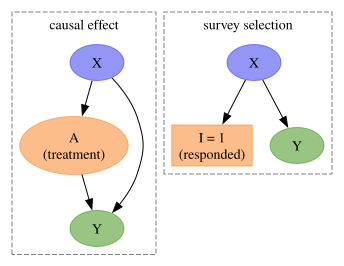

In [5]:
dag = gr.Digraph()

with dag.subgraph(name="cluster_causal") as c:
    c.attr(label="causal effect", style="dashed", color="gray")
    c.node("X_c", label="X", color="#2a2eec80", style="filled")
    c.node("A", label="A\n(treatment)", color="#fa7c1780", style="filled")
    c.node("Y_c", label="Y", color="#328c0680", style="filled")
    c.edge("X_c", "A")
    c.edge("X_c", "Y_c")
    c.edge("A", "Y_c")

with dag.subgraph(name="cluster_survey") as c:
    c.attr(label="survey selection", style="dashed", color="gray")
    c.node("X_s", label="X", color="#2a2eec80", style="filled")
    c.node(
        "I", label="I = 1\n(responded)", shape="box", color="#fa7c1780", style="filled"
    )
    c.node("Y_s", label="Y", color="#328c0680", style="filled")
    c.edge("X_s", "I")
    c.edge("X_s", "Y_s")

dag

In both graphs $X$ is the common cause we adjust for. The differences are the node we act on and one arrow. In the causal case we intervene on $A$ and ask for the outcome under $A = a$. In the survey case we "intervene" on $I$ and ask for the outcome if everyone had responded. And $I$ has no arrow into $Y$: responding does not change the answer, so the target is simply $\text{E}[Y]$.

| | g-formula (causal effect) | poststratification (MRP) |
|---|---|---|
| target | $\text{E}[Y^a]$ | $\text{E}[Y]$ in the population |
| what the data can estimate | $\text{E}[Y \mid A = a, X = x]$ | $\text{E}[Y \mid X = x, I = 1]$ |
| distribution we average over | $\text{P}(X = x)$, from the sample or from a target population | $N_j / N$, from the census |
| what the adjustment removes | confounding | selection bias |
| identifying independence | $Y^a \perp A \mid X$ | $Y \perp I \mid X$ |
| positivity | $0 < \text{P}(A = a \mid X = x) < 1$ | $\text{P}(I = 1 \mid X = x_j) > 0$ for all cells with $N_j > 0$ |
| typical failure | an unmeasured confounder $U$ | an unmeasured $U$ with $U \to I$ and $U \to Y$, or $Y \to I$ |
| Bayesian computation | for each draw, predict under $A = a$ for every $x$ and average | for each draw, predict $\theta_j$ for every cell and average with $N_j$ |

Three consequences follow.

1. The estimand is a nonlinear function of the parameters. We average on the probability scale, not on the logit scale. Priors that look harmless on the $\theta_j$ can matter after the average, exactly as in causal standardization. This is why we compute $\theta^{\text{PS}}$ inside the model, as part of the estimand, and not as post-processing.
2. In PyMC both computations are one line. For MRP it is `(N * theta).sum() / N.sum()` over the cells. For a causal effect it is the mean of the predictions under `pm.do` over the covariate rows, as in the earlier post [Introduction to Causal Inference with PPLs](https://juanitorduz.github.io/intro_causal_inference_ppl_pymc/).
3. We can change the population. If we replace $\text{P}(X)$ by the covariate distribution $\text{P}^*(X)$ of a different target population, we get the transport formula $\sum_x \text{E}[Y \mid X = x, I = 1] \, \text{P}^*(X = x)$. Poststratifying with a new set of counts $N^*_j$ is the same thing, and we do it below without refitting. An experiment run on a non-representative group of participants needs both adjustments at once: $\sum_x \text{E}[Y \mid A = a, X = x, I = 1] \, \text{P}^*(X = x)$.

## Data Generating Process

We simulate the population and the survey with PyMC itself, following the pattern of the [PyMC-Marketing data generator](https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_data_generator.html). We write the world as a generative model, we fix the true parameters with the `do` operator, and we take one draw. The truth is a deterministic node of this model, so the true cell probabilities and the true poststratified quantities come out of the same draw as the data.

We use the [`pymc.dims` module](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/dims_module.html) for the model. Every variable carries named dimensions, arithmetic aligns by name, and reductions are by name. The frame is a three-dimensional array with dimensions `age`, `eth` and `state`, and we never write an index array.

The generative model has four parts.

1. The census. The population counts $N_j$ are drawn once from a log-normal distribution and then treated as known. The state-level predictor $v_s$ is drawn once too.
2. The answers. The true cell probabilities $\theta_j$ follow the additive logit model of Step 1.
3. The response mechanism. The probability that a person responds, $\pi_j$, depends on age and ethnicity only. This is the first DAG by construction. The probability that a given respondent comes from cell $j$ is $p_j \propto \pi_j N_j$, and with $n$ respondents in total the expected number in cell $j$ is $n \, p_j$.
4. The counts. We draw the "yes" and the "no" counts of cell $j$ as independent Poisson variables with means $n \, p_j \, \theta_j$ and $n \, p_j \, (1 - \theta_j)$. The total $n_j$ is then Poisson with mean $n \, p_j$, and given $n_j$ the "yes" count is $\text{Binomial}(n_j, \theta_j)$, which is the likelihood of Step 1.

The argument `response_ratio` multiplies the mean of the "yes" count. With `response_ratio=1.0` the response does not depend on the answer. We use a value above one later to break the assumption on purpose.

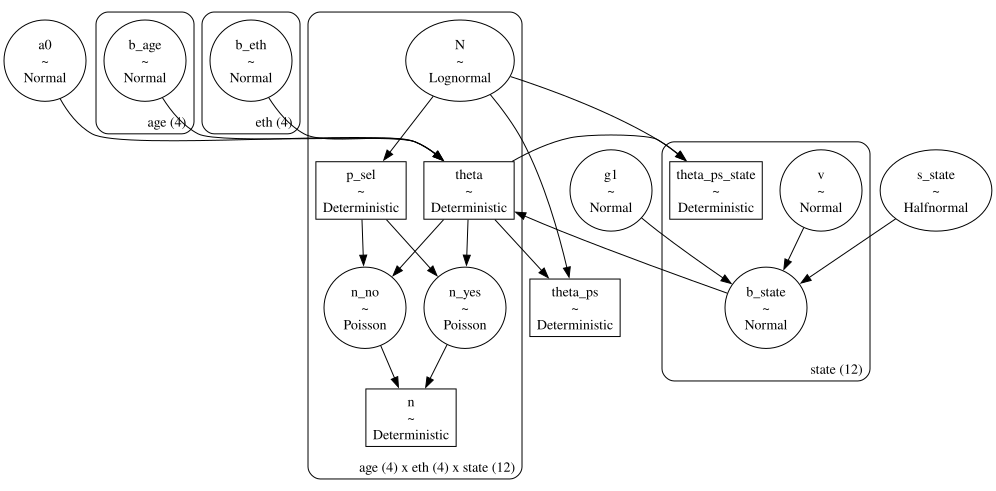

In [6]:
ages = ["18-29", "30-44", "45-64", "65+"]
eths = ["white", "black", "hispanic", "other"]
states = [f"S{i:02d}" for i in range(12)]

coords = {"age": ages, "eth": eths, "state": states}
frame_dims = ("age", "eth", "state")

n_respondents = 1_500


def make_generative_model(response_ratio: float = 1.0) -> pm.Model:
    with pm.Model(coords=coords) as model:
        # census: population counts per cell and a state-level predictor
        N = pmd.LogNormal("N", mu=np.log(50_000), sigma=0.7, dims=frame_dims)  # noqa: N806
        v = pmd.Normal("v", mu=0, sigma=1, dims="state")

        # parameters of the answer model, fixed below with the do operator
        a0 = pmd.Normal("a0", mu=0, sigma=1)
        b_age = pmd.Normal("b_age", mu=0, sigma=1, dims="age")
        b_eth = pmd.Normal("b_eth", mu=0, sigma=1, dims="eth")
        g1 = pmd.Normal("g1", mu=0, sigma=1)
        s_state = pmd.HalfNormal("s_state", sigma=1)
        b_state = pmd.Normal("b_state", mu=g1 * v, sigma=s_state, dims="state")

        # true cell probabilities and true poststratified quantities
        theta = pmd.Deterministic(
            "theta", pmd.math.sigmoid(a0 + b_age + b_eth + b_state)
        )
        pmd.Deterministic("theta_ps", (N * theta).sum(frame_dims) / N.sum(frame_dims))
        pmd.Deterministic(
            "theta_ps_state", (N * theta).sum(("age", "eth")) / N.sum(("age", "eth"))
        )

        # response mechanism: depends on age and ethnicity only
        age_score = pmd.as_xtensor(np.arange(len(ages), dtype=float), dims=("age",))
        eth_score = pmd.as_xtensor(np.arange(len(eths), dtype=float), dims=("eth",))
        propensity = pmd.math.sigmoid(2.0 - 1.0 * age_score - 0.6 * eth_score)
        p_sel = pmd.Deterministic(
            "p_sel", (propensity * N) / (propensity * N).sum(frame_dims)
        )

        # "yes" and "no" counts per cell
        n_yes = pmd.Poisson("n_yes", mu=n_respondents * p_sel * theta * response_ratio)
        n_no = pmd.Poisson("n_no", mu=n_respondents * p_sel * (1 - theta))
        pmd.Deterministic("n", n_yes + n_no)

    return model


generative_model = make_generative_model()

pm.model_to_graphviz(generative_model)

We fix the parameters of the answer model at their true values with `pm.do`. The census, the state effects and the counts remain random, and we draw them once.

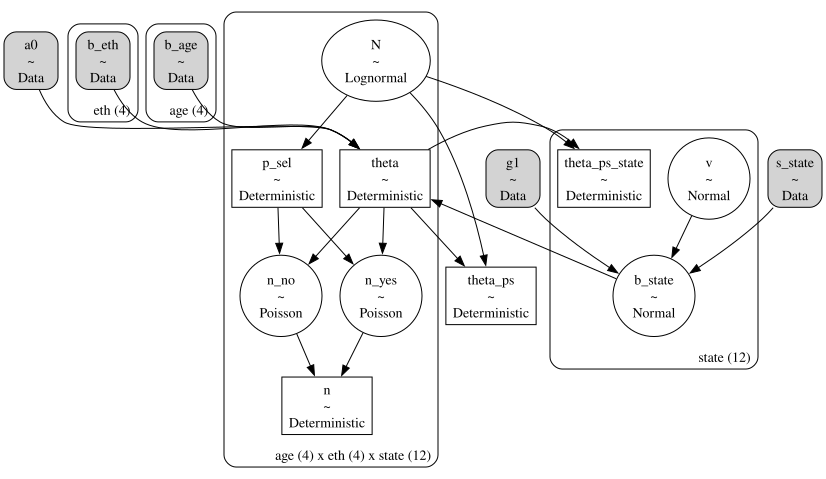

In [7]:
true_values = {
    "a0": -0.2,
    "b_age": np.array([-0.8, -0.2, 0.3, 0.9]),
    "b_eth": np.array([0.5, -1.2, -0.4, 0.1]),
    "g1": 0.7,
    "s_state": 0.3,
}

generative_model_true = pm.do(generative_model, true_values)

pm.model_to_graphviz(generative_model_true)

In [8]:
with generative_model_true:
    simulation = pm.sample_prior_predictive(draws=1, random_seed=rng)

world = simulation["prior"].to_dataset().sel(chain=0, draw=0)

N_cell = np.round(world["N"].to_numpy()).astype(int)
v_state = world["v"].to_numpy()
n_cell = world["n"].to_numpy().astype(int)
y_cell = world["n_yes"].to_numpy().astype(int)

theta_true = world["theta"].to_numpy()
theta_ps_true = world["theta_ps"].item()
theta_ps_state_true = world["theta_ps_state"].to_numpy()

print(
    f"cells: {N_cell.size}, population: {N_cell.sum():,}, respondents: {n_cell.sum():,}"
)
print(f"cells without respondents: {(n_cell == 0).sum()}")
print(f"true population share: {theta_ps_true:.4f}")

Sampling: [N, b_state, n_no, n_yes, v]


cells: 192, population: 12,823,179, respondents: 1,510
cells without respondents: 11
true population share: 0.4172


The poststratification frame is the long table of cells with their population counts. In a real project this table comes first, and its counts come from a census or a large reference survey. Here we add the survey counts and the true probabilities to the same table.

In [9]:
frame = pl.DataFrame(
    data=list(itertools.product(ages, eths, states)),
    schema=["age", "eth", "state"],
    orient="row",
).with_columns(
    N=N_cell.ravel(),
    n=n_cell.ravel(),
    y=y_cell.ravel(),
    theta_true=theta_true.ravel(),
)

frame.head()

age,eth,state,N,n,y,theta_true
str,str,str,i64,i64,i64,f64
"""18-29""","""white""","""S00""",26698,9,7,0.622136
"""18-29""","""white""","""S01""",68307,12,3,0.416046
"""18-29""","""white""","""S02""",30479,10,1,0.216148
"""18-29""","""white""","""S03""",20549,10,2,0.260268
"""18-29""","""white""","""S04""",14116,2,0,0.496976


The sample is heavily skewed by construction. We compare the population shares with the sample shares by age group.

In [10]:
composition = (
    frame.group_by("age", maintain_order=True)
    .agg(pl.col("N").sum(), pl.col("n").sum())
    .with_columns(
        population_share=pl.col("N") / pl.col("N").sum(),
        sample_share=pl.col("n") / pl.col("n").sum(),
    )
)

composition

age,N,n,population_share,sample_share
str,i64,i64,f64,f64
"""18-29""",2502182,544,0.19513,0.360265
"""30-44""",3973761,562,0.309889,0.372185
"""45-64""",3241041,277,0.252749,0.183444
"""65+""",3106195,127,0.242233,0.084106


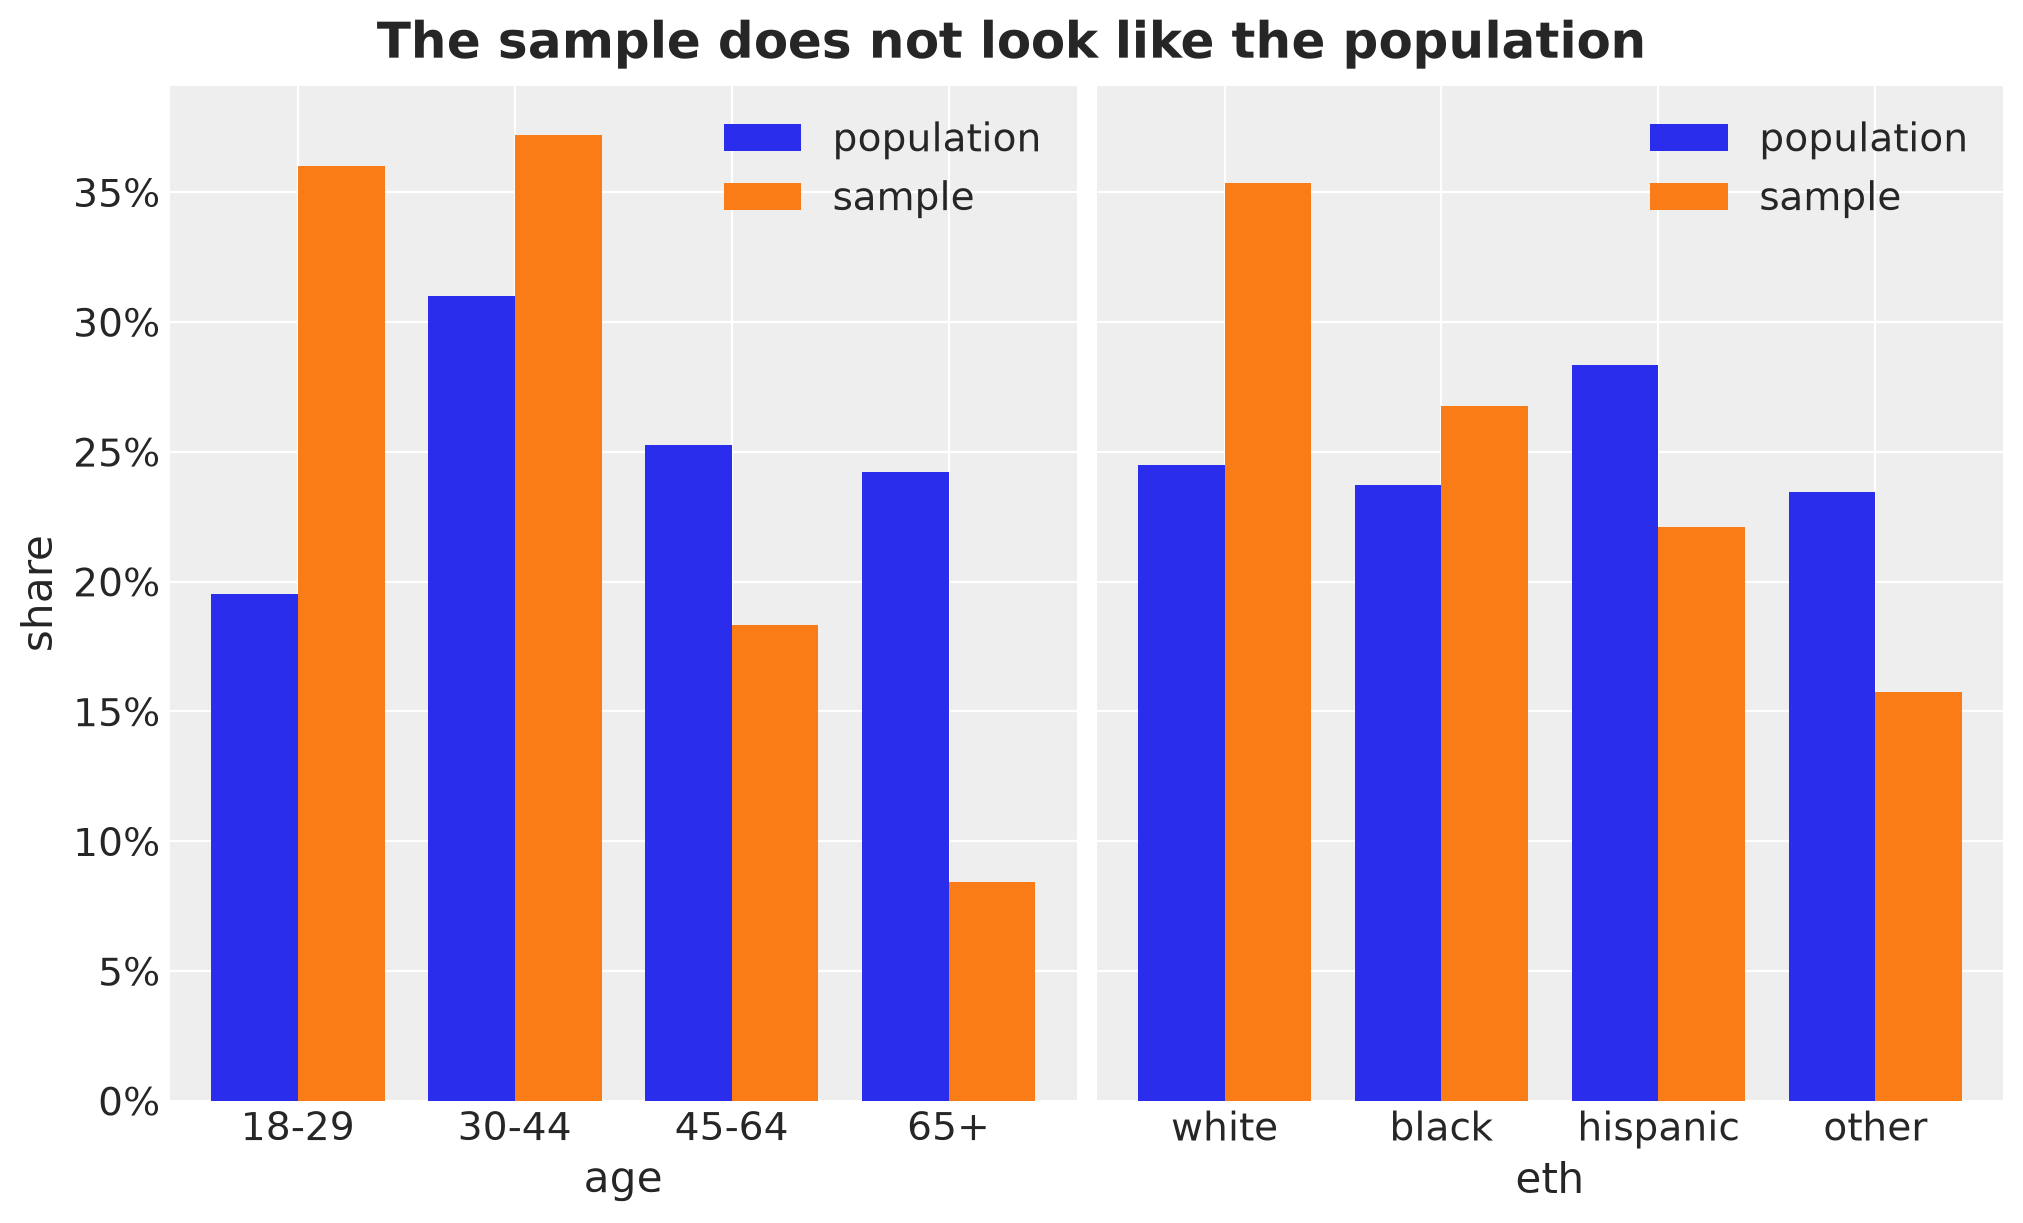

In [11]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(10, 6), sharey=True, layout="constrained"
)

for ax, factor in zip(axes, ["age", "eth"], strict=True):
    shares = (
        frame.group_by(factor, maintain_order=True)
        .agg(pl.col("N").sum(), pl.col("n").sum())
        .with_columns(
            population=pl.col("N") / pl.col("N").sum(),
            sample=pl.col("n") / pl.col("n").sum(),
        )
    )
    x = np.arange(shares.height)
    ax.bar(x - 0.2, shares["population"], width=0.4, color="C0", label="population")
    ax.bar(x + 0.2, shares["sample"], width=0.4, color="C1", label="sample")
    ax.set_xticks(x, shares[factor].to_list())
    ax.set(xlabel=factor)
    ax.legend()

axes[0].set(ylabel="share")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))


fig.suptitle(
    "The sample does not look like the population", fontsize=18, fontweight="bold"
);

Because the young respond more and, in this world, the young lean "no", the raw sample mean is biased downward.

In [12]:
raw_mean = y_cell.sum() / n_cell.sum()

print(f"raw sample mean : {raw_mean:.4f}")
print(f"true value      : {theta_ps_true:.4f}")
print(f"bias            : {raw_mean - theta_ps_true:+.4f}")

raw sample mean : 0.3656
true value      : 0.4172
bias            : -0.0516


## The MRP Model

The model follows Step 1 and Step 2, with three implementation choices.

- `ZeroSumNormal` priors on the age and ethnicity effects. Without the constraint the intercept and the level means trade off freely, and the sampler wanders along that ridge.
- Non-centered state effects: `a_state = g1 * v + s_state * z_state` with `z_state` standard normal. This keeps the funnel geometry away from NUTS when the state-level scale is small.
- Poststratification inside the model. The linear predictor is computed for *all* cells on the `age x eth x state` grid, so the same tensor serves the likelihood and the poststratification. The two estimands are `Deterministic` nodes. Cells without respondents enter the likelihood with $n_j = 0$ and contribute nothing, but they still receive a $\theta_j$ and a weight $N_j$.

With `pymc.dims`, the sum `a0 + a_age + a_eth + a_state` broadcasts by dimension name to the full grid, and `.sum(("age", "eth"))` collapses the grid to one value per state. The population counts are `pmd.Data`, so we can replace them later without refitting. The dims module does not include a Binomial distribution yet, so for the likelihood we convert to regular tensors with `.values` and use `pm.Binomial`.

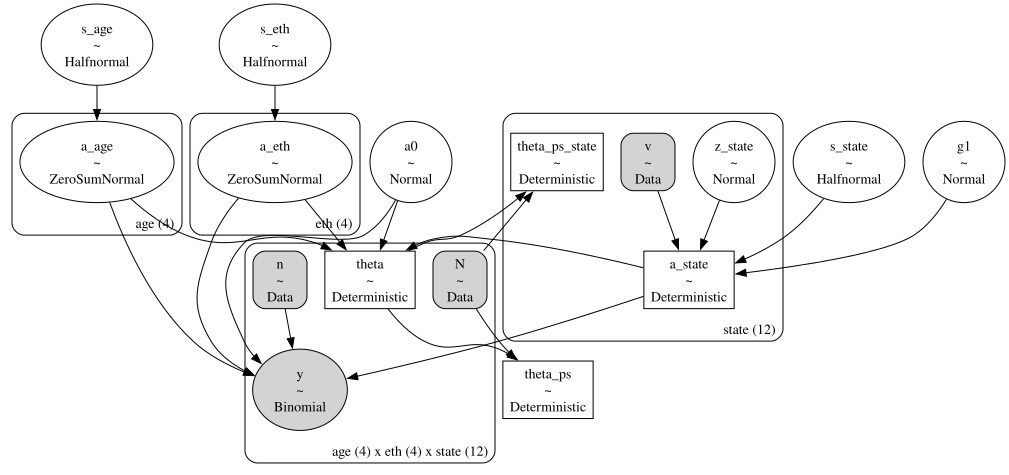

In [13]:
def make_mrp_model(
    N: np.ndarray,  # noqa: N803
    v: np.ndarray,
    n: np.ndarray,
    y: np.ndarray,
) -> pm.Model:
    with pm.Model(coords=coords) as model:
        # data: census counts, state-level predictor and respondents per cell
        N_data = pmd.Data("N", N.astype(float), dims=frame_dims)  # noqa: N806
        v_data = pmd.Data("v", v, dims="state")
        n_data = pmd.Data("n", n, dims=frame_dims)

        # priors
        a0 = pmd.Normal("a0", mu=0, sigma=1.5)
        s_age = pmd.HalfNormal("s_age", sigma=1)
        s_eth = pmd.HalfNormal("s_eth", sigma=1)
        s_state = pmd.HalfNormal("s_state", sigma=1)
        a_age = pmd.ZeroSumNormal("a_age", sigma=s_age, core_dims="age", dims="age")
        a_eth = pmd.ZeroSumNormal("a_eth", sigma=s_eth, core_dims="eth", dims="eth")
        g1 = pmd.Normal("g1", mu=0, sigma=1)
        z_state = pmd.Normal("z_state", mu=0, sigma=1, dims="state")
        a_state = pmd.Deterministic("a_state", g1 * v_data + s_state * z_state)

        # step 1: the conditional surface over all cells
        eta = (a0 + a_age + a_eth + a_state).transpose(*frame_dims)
        theta = pmd.Deterministic("theta", pmd.math.sigmoid(eta), dims=frame_dims)

        # step 2: poststratification inside the model
        pmd.Deterministic(
            "theta_ps", (N_data * theta).sum(frame_dims) / N_data.sum(frame_dims)
        )
        pmd.Deterministic(
            "theta_ps_state",
            (N_data * theta).sum(("age", "eth")) / N_data.sum(("age", "eth")),
        )

        # likelihood: the dims module has no Binomial yet, so we use regular tensors
        pm.Binomial(
            "y", n=n_data.values, logit_p=eta.values, observed=y, dims=frame_dims
        )

    return model


mrp_model = make_mrp_model(N=N_cell, v=v_state, n=n_cell, y=y_cell)

pm.model_to_graphviz(mrp_model)

### Prior Predictive Check

Before we look at the data we check what the priors say about the estimand.

Sampling: [a0, a_age, a_eth, g1, s_age, s_eth, s_state, y, z_state]


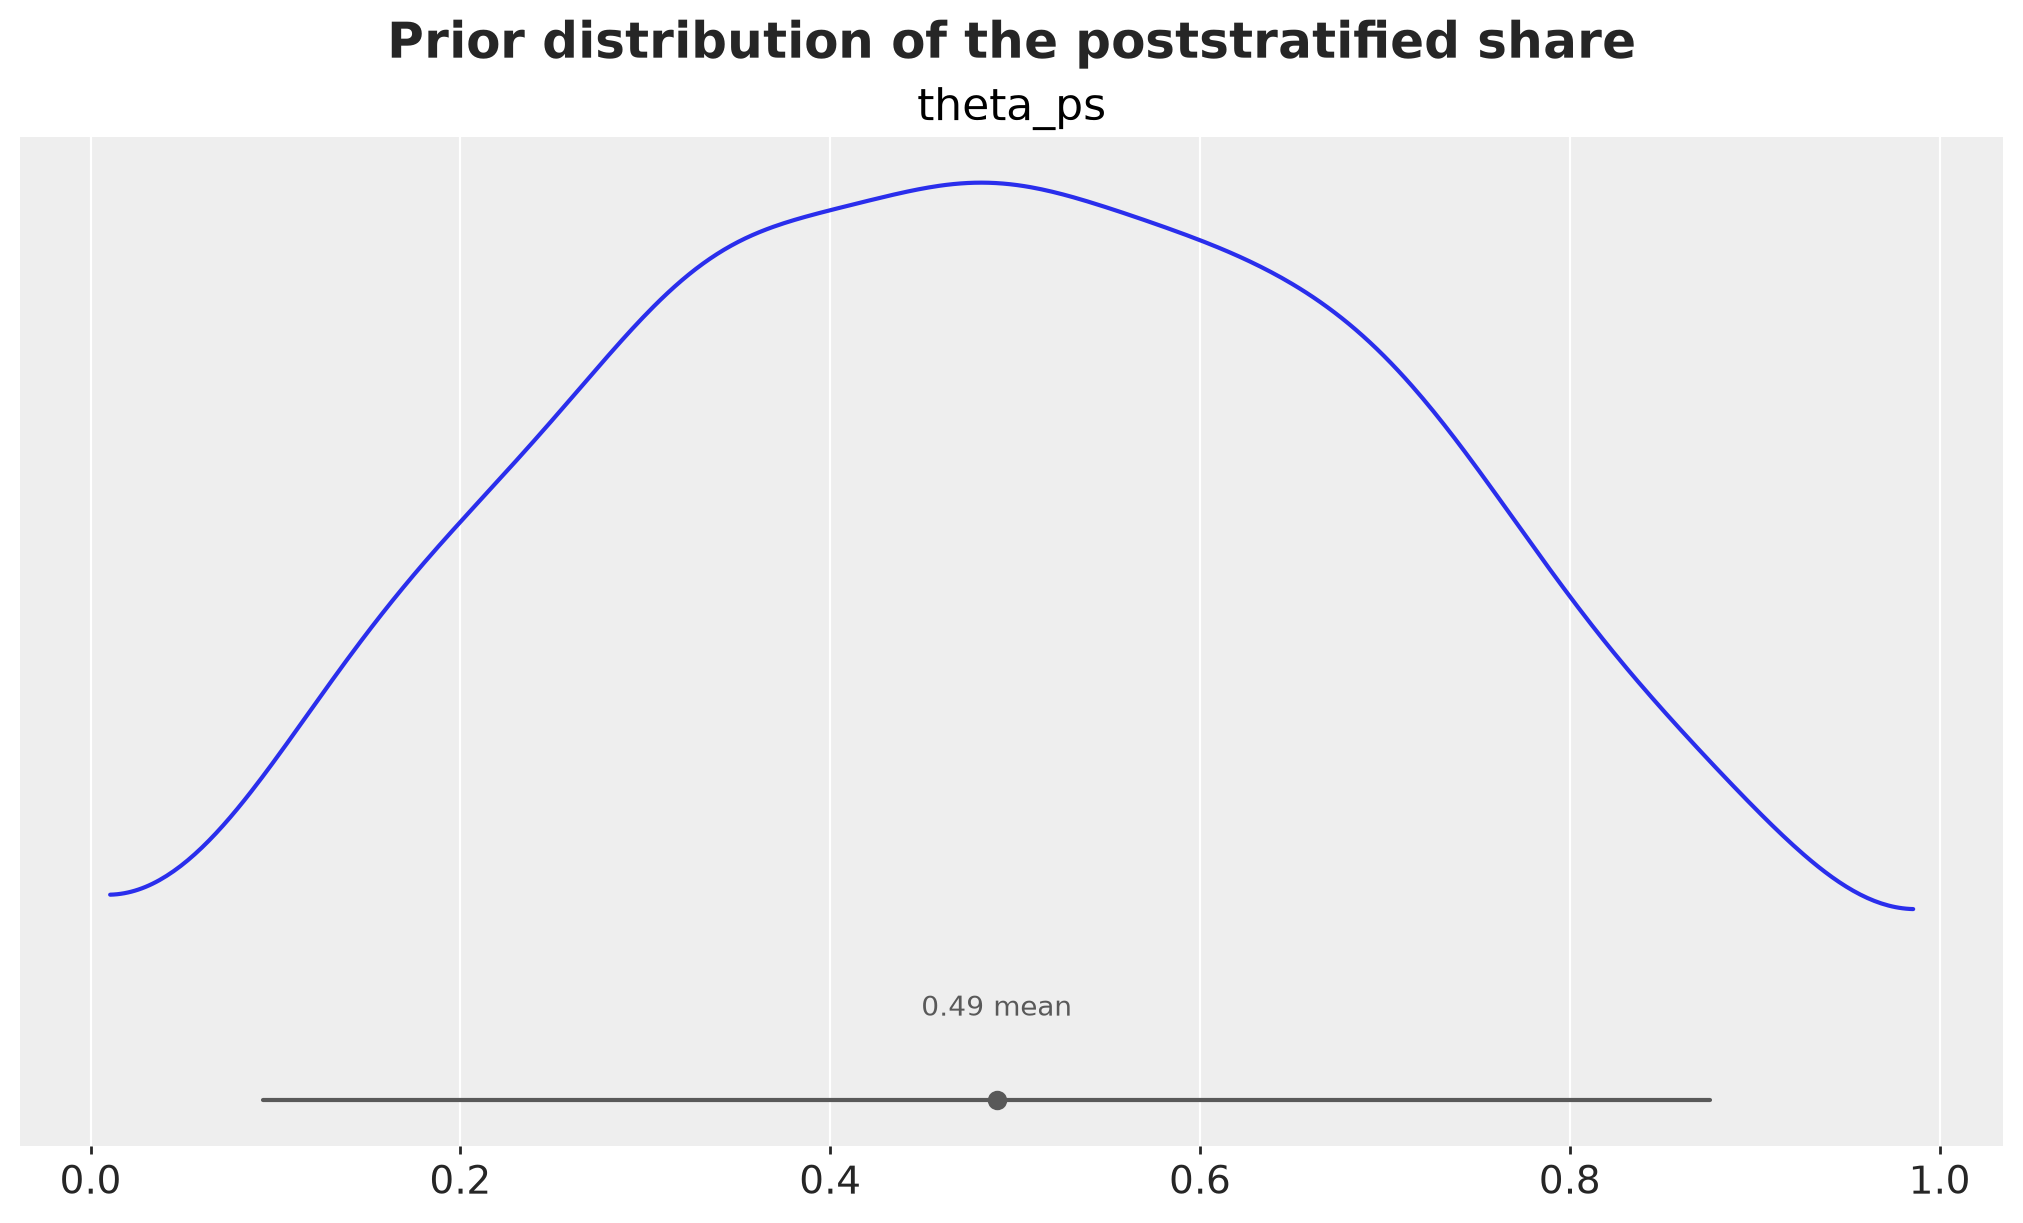

In [14]:
with mrp_model:
    prior_predictive = pm.sample_prior_predictive(draws=1_000, random_seed=rng)

pc = az.plot_dist(
    prior_predictive,
    group="prior",
    var_names=["theta_ps"],
    figure_kwargs={"figsize": (10, 6)},
)
pc.viz["figure"].item().suptitle(
    "Prior distribution of the poststratified share", fontsize=18, fontweight="bold"
);

Overall, the induced prior on $\theta^{\text{PS}}$ is wide, which is what we want from weakly informative priors on the logit scale.

## Model Fit and Diagnostics

We now fit the model to the data.

In [15]:
with mrp_model:
    idata = pm.sample(
        draws=1_000,
        tune=1_000,
        chains=4,
        random_seed=rng,
        progressbar=False,
    )

idata["prior"] = prior_predictive["prior"]

NUTS[nutpie]: [a0, s_age, s_eth, s_state, a_age, a_eth, g1, z_state]


Let's see some diagnostics.

In [16]:
az.diagnose(idata);

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


In [17]:
var_names = ["a0", "g1", "s_age", "s_eth", "s_state", "theta_ps"]

az.summary(idata, var_names=var_names, ci_prob=HDI_PROB, ci_kind="hdi")

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a0,-0.262,0.103,-0.46,-0.068,1496,1660,1.00,0.0027,0.0022
g1,0.943,0.106,0.74,1.1,1391,1672,1.00,0.0029,0.0024
s_age,0.98,0.37,0.47,1.8,4298,3035,1.00,0.0058,0.0057
s_eth,0.91,0.36,0.43,1.8,4410,3060,1.00,0.0058,0.0058
s_state,0.199,0.107,0.019,0.42,775,700,1.00,0.0037,0.0028
theta_ps,0.4301,0.0142,0.4,0.46,2545,2989,1.00,0.00028,0.0002


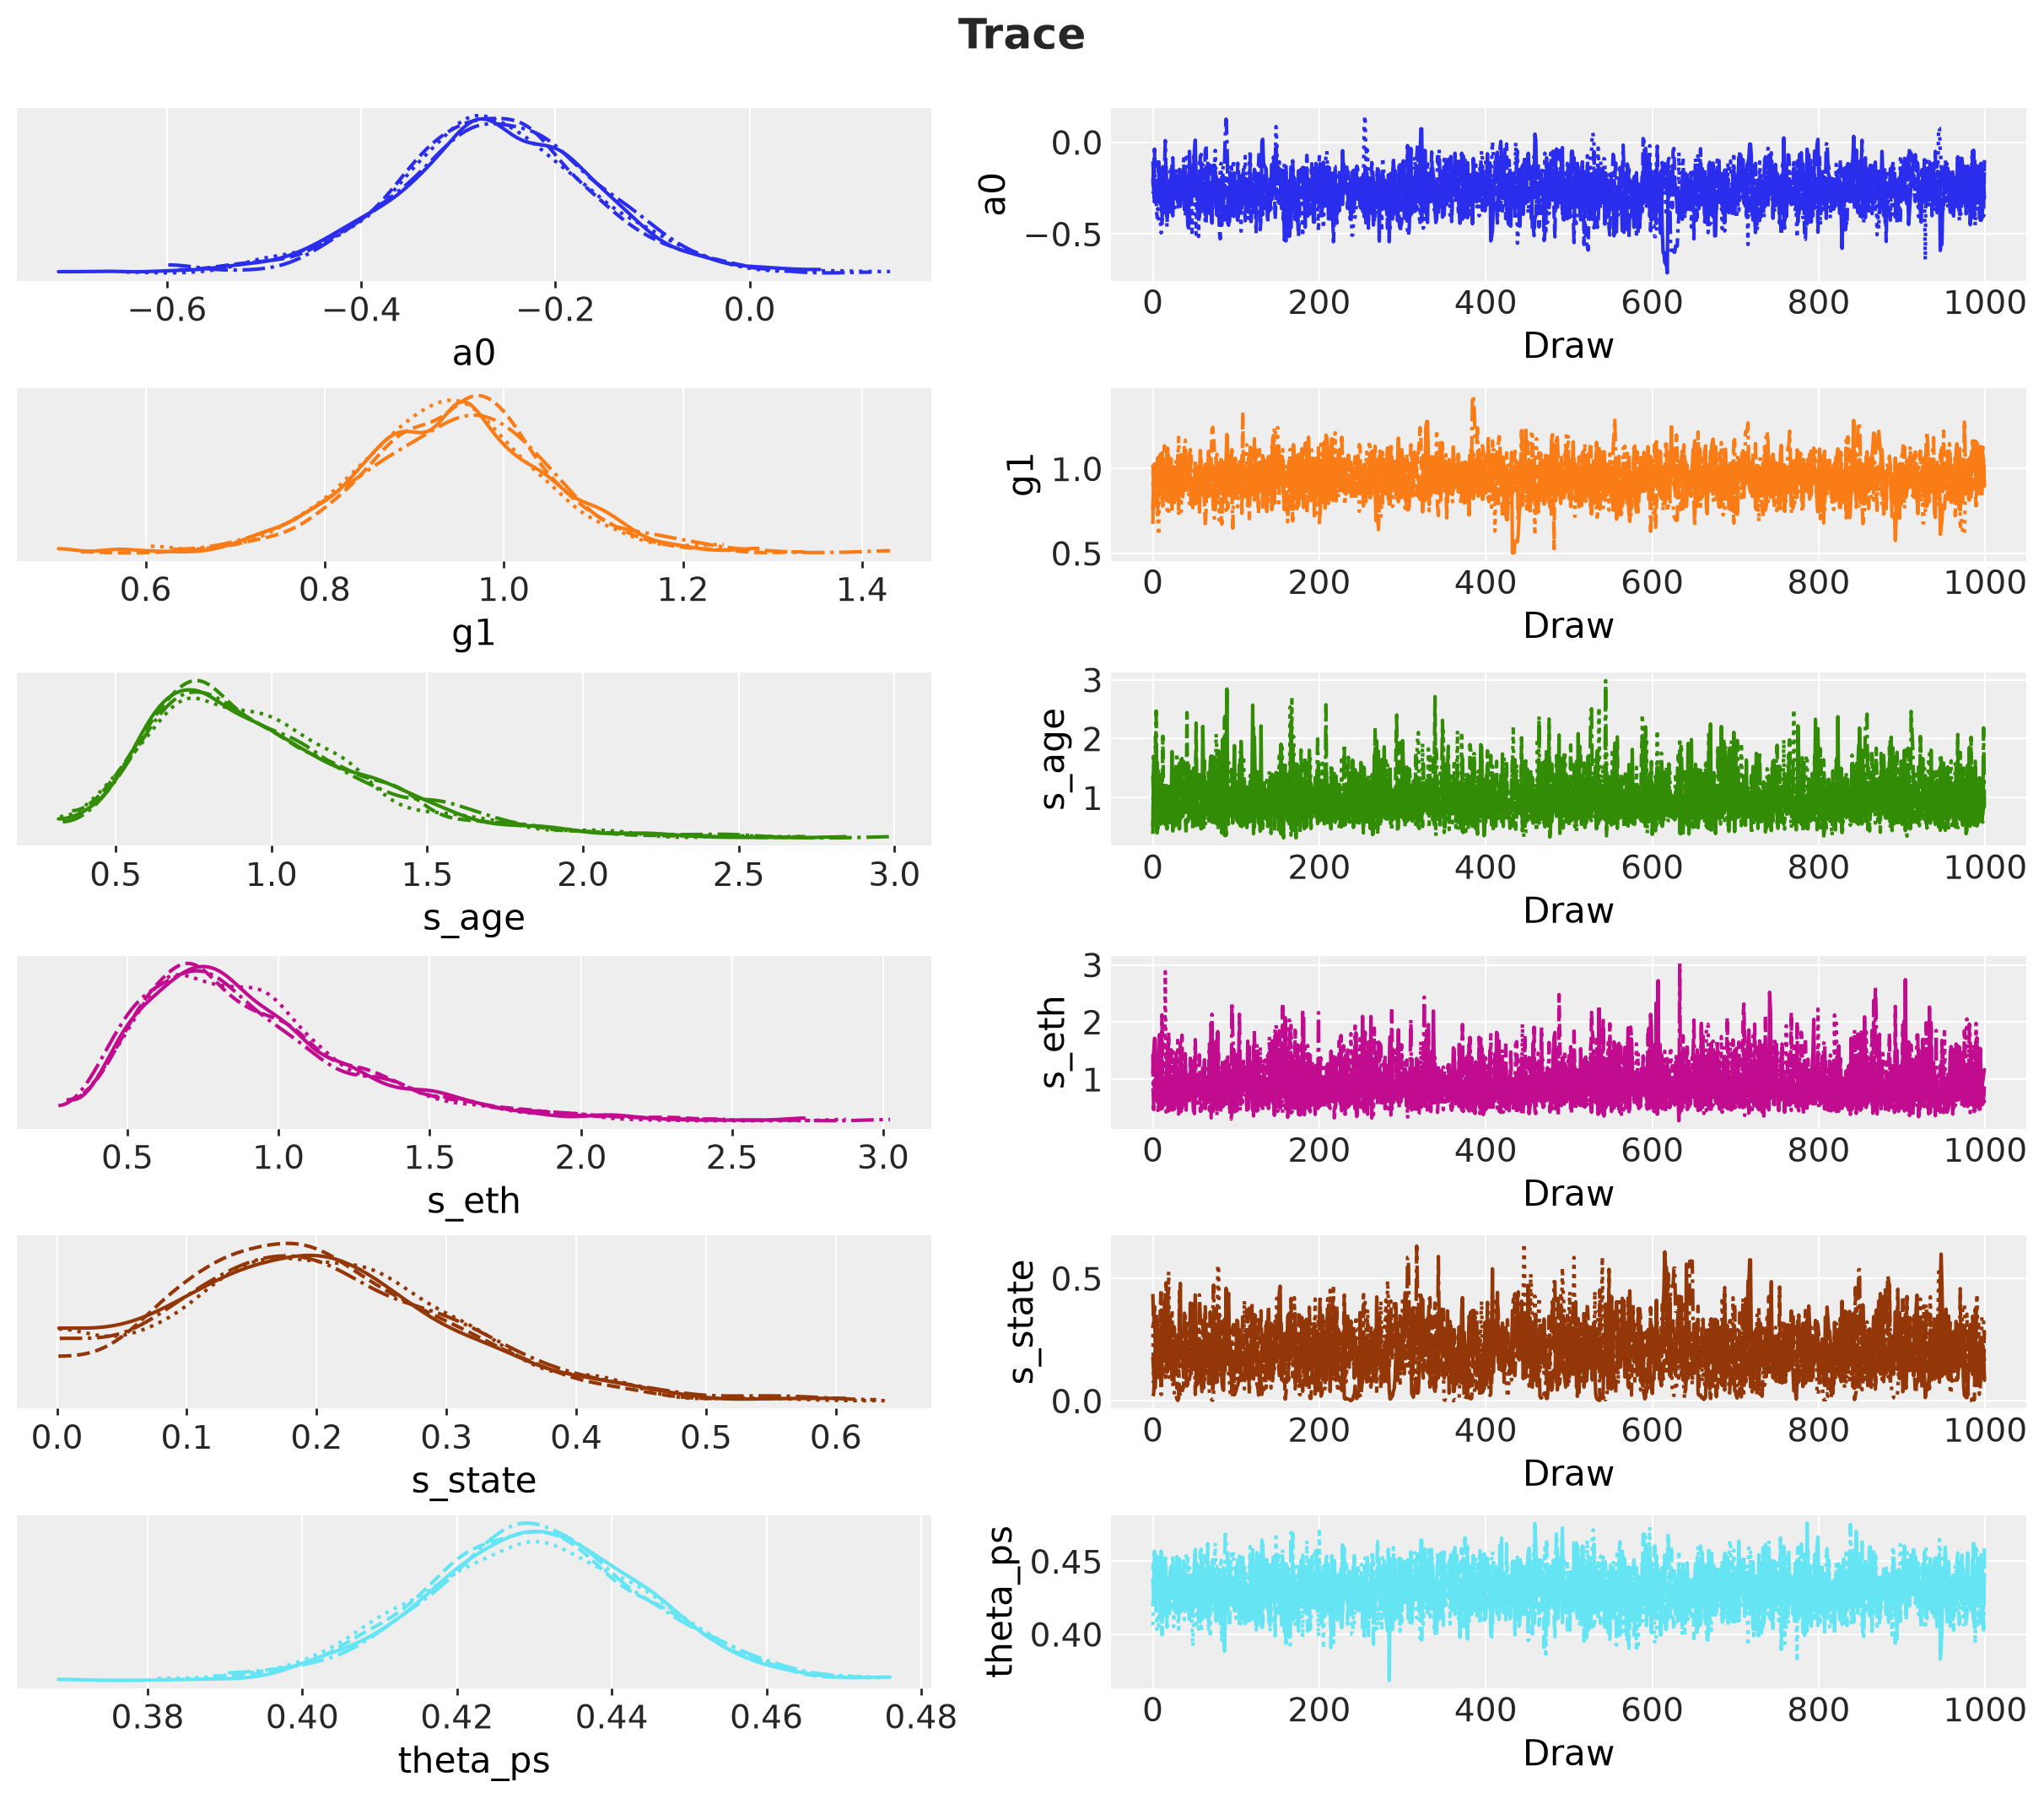

In [18]:
pc = az.plot_trace_dist(idata, var_names=var_names, figure_kwargs={"figsize": (12, 10)})
pc.viz["figure"].item().suptitle("Trace", fontsize=18, fontweight="bold", y=1.05);

Overall, the model diagnostics look good.

## Results

### Population Share

We compare the posterior of $\theta^{\text{PS}}$ with the truth and with the raw sample mean.

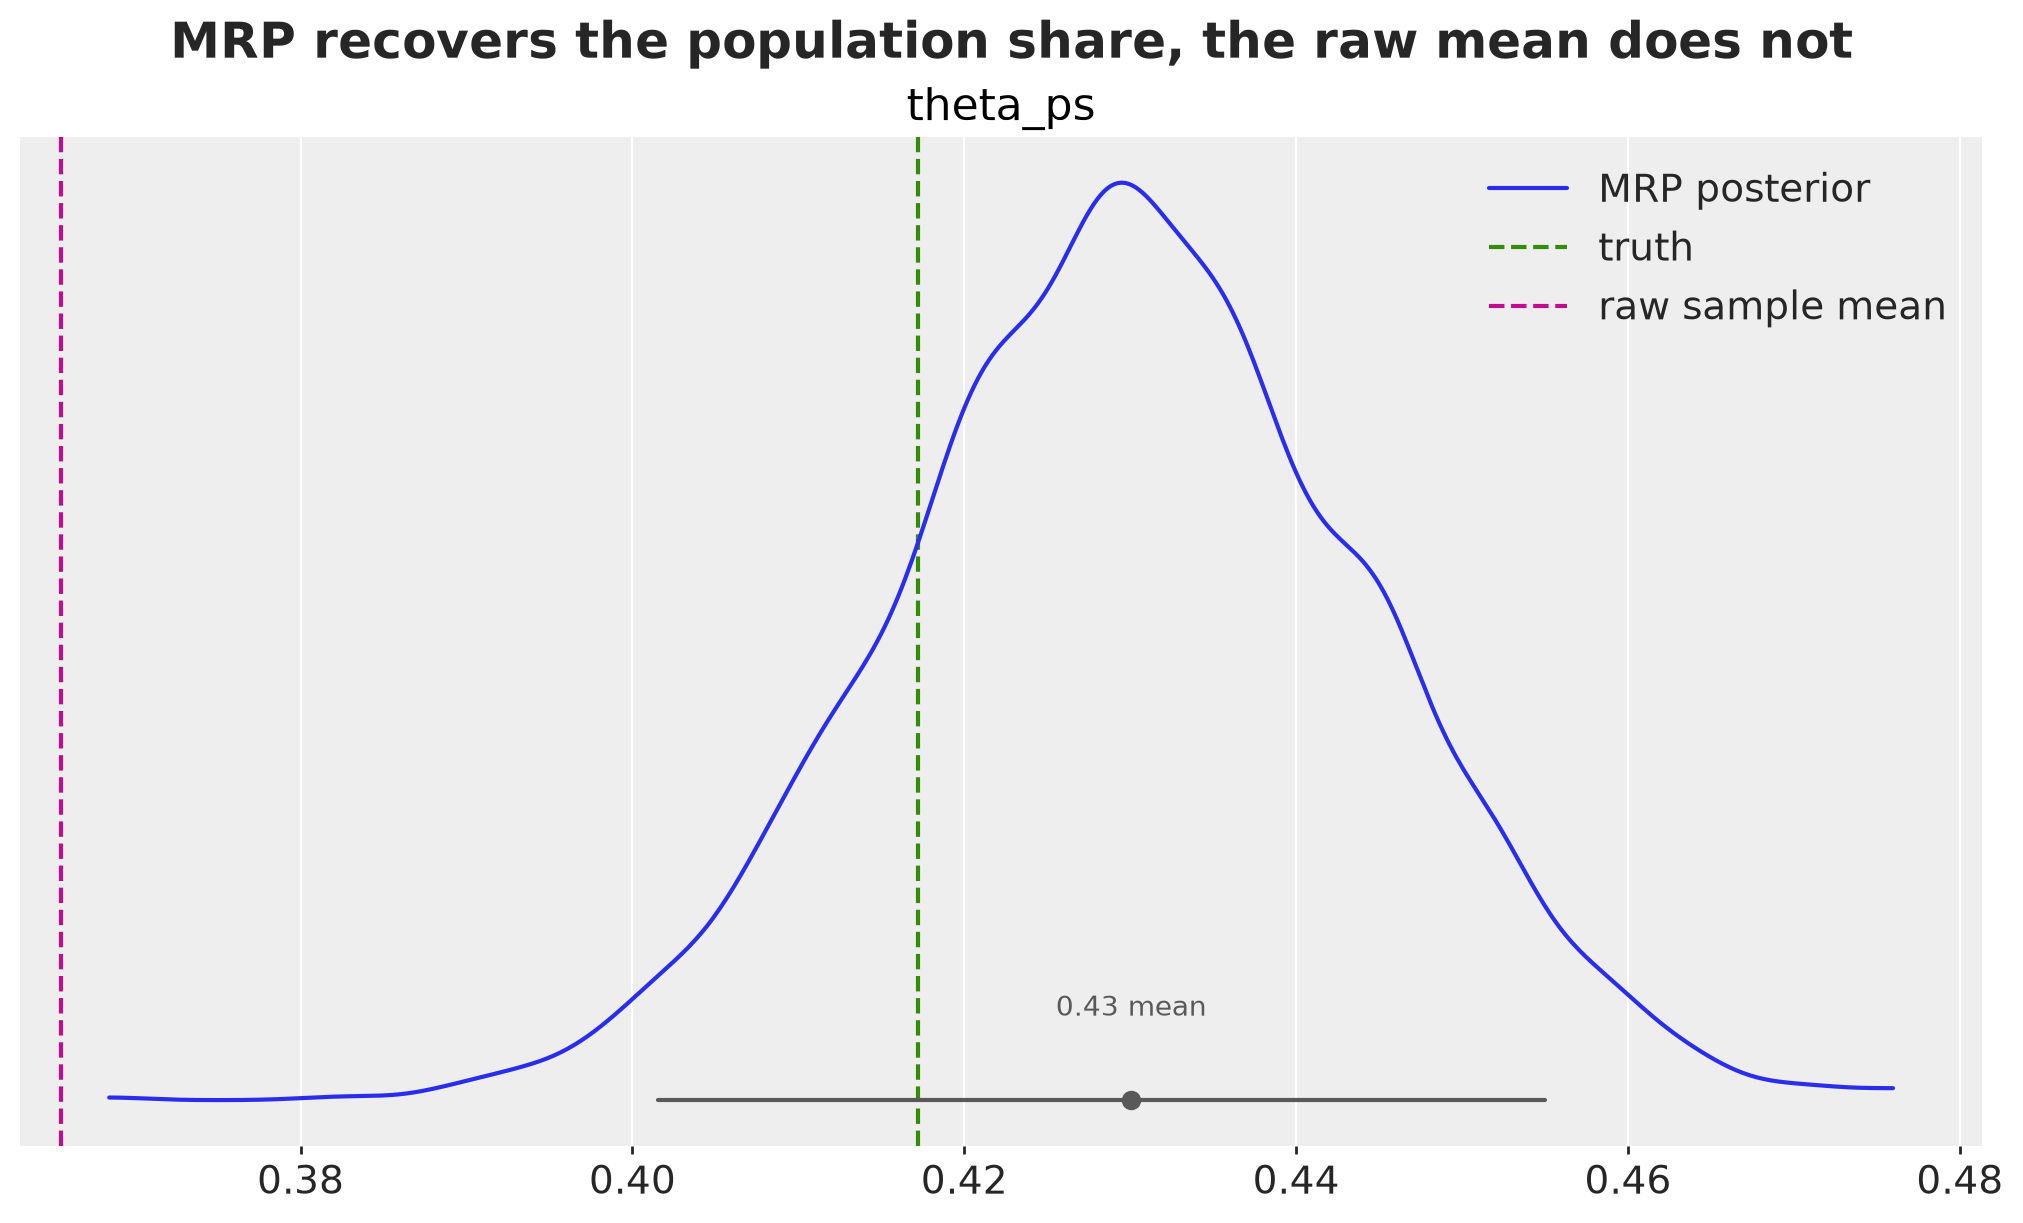

In [19]:
pc = az.plot_dist(idata, var_names=["theta_ps"], figure_kwargs={"figsize": (10, 6)})
az.add_lines(
    pc,
    values={"theta_ps": theta_ps_true},
    visuals={"ref_line": {"color": "C2", "label": "truth"}},
)
az.add_lines(
    pc,
    values={"theta_ps": raw_mean},
    visuals={
        "ref_line": {"color": "C3", "linestyle": "--", "label": "raw sample mean"}
    },
)
pc.viz["dist"]["theta_ps"].item().set_label("MRP posterior")
ax = pc.get_target("theta_ps", {})
ax.legend(loc="upper right")
pc.viz["figure"].item().suptitle(
    "MRP recovers the population share, the raw mean does not",
    fontsize=18,
    fontweight="bold",
);

We see that the MRP estimate is close to the true value.

### State-Level Estimates

This is where MRP earns its reputation. Some states have fewer than one hundred respondents spread over sixteen cells, but their estimates borrow strength from the national pattern and from the state-level predictor $v_s$. We compare the posterior of $\theta^{\text{PS}}_s$ with the truth and with the raw mean of the respondents of each state. The labels show the number of respondents per state.

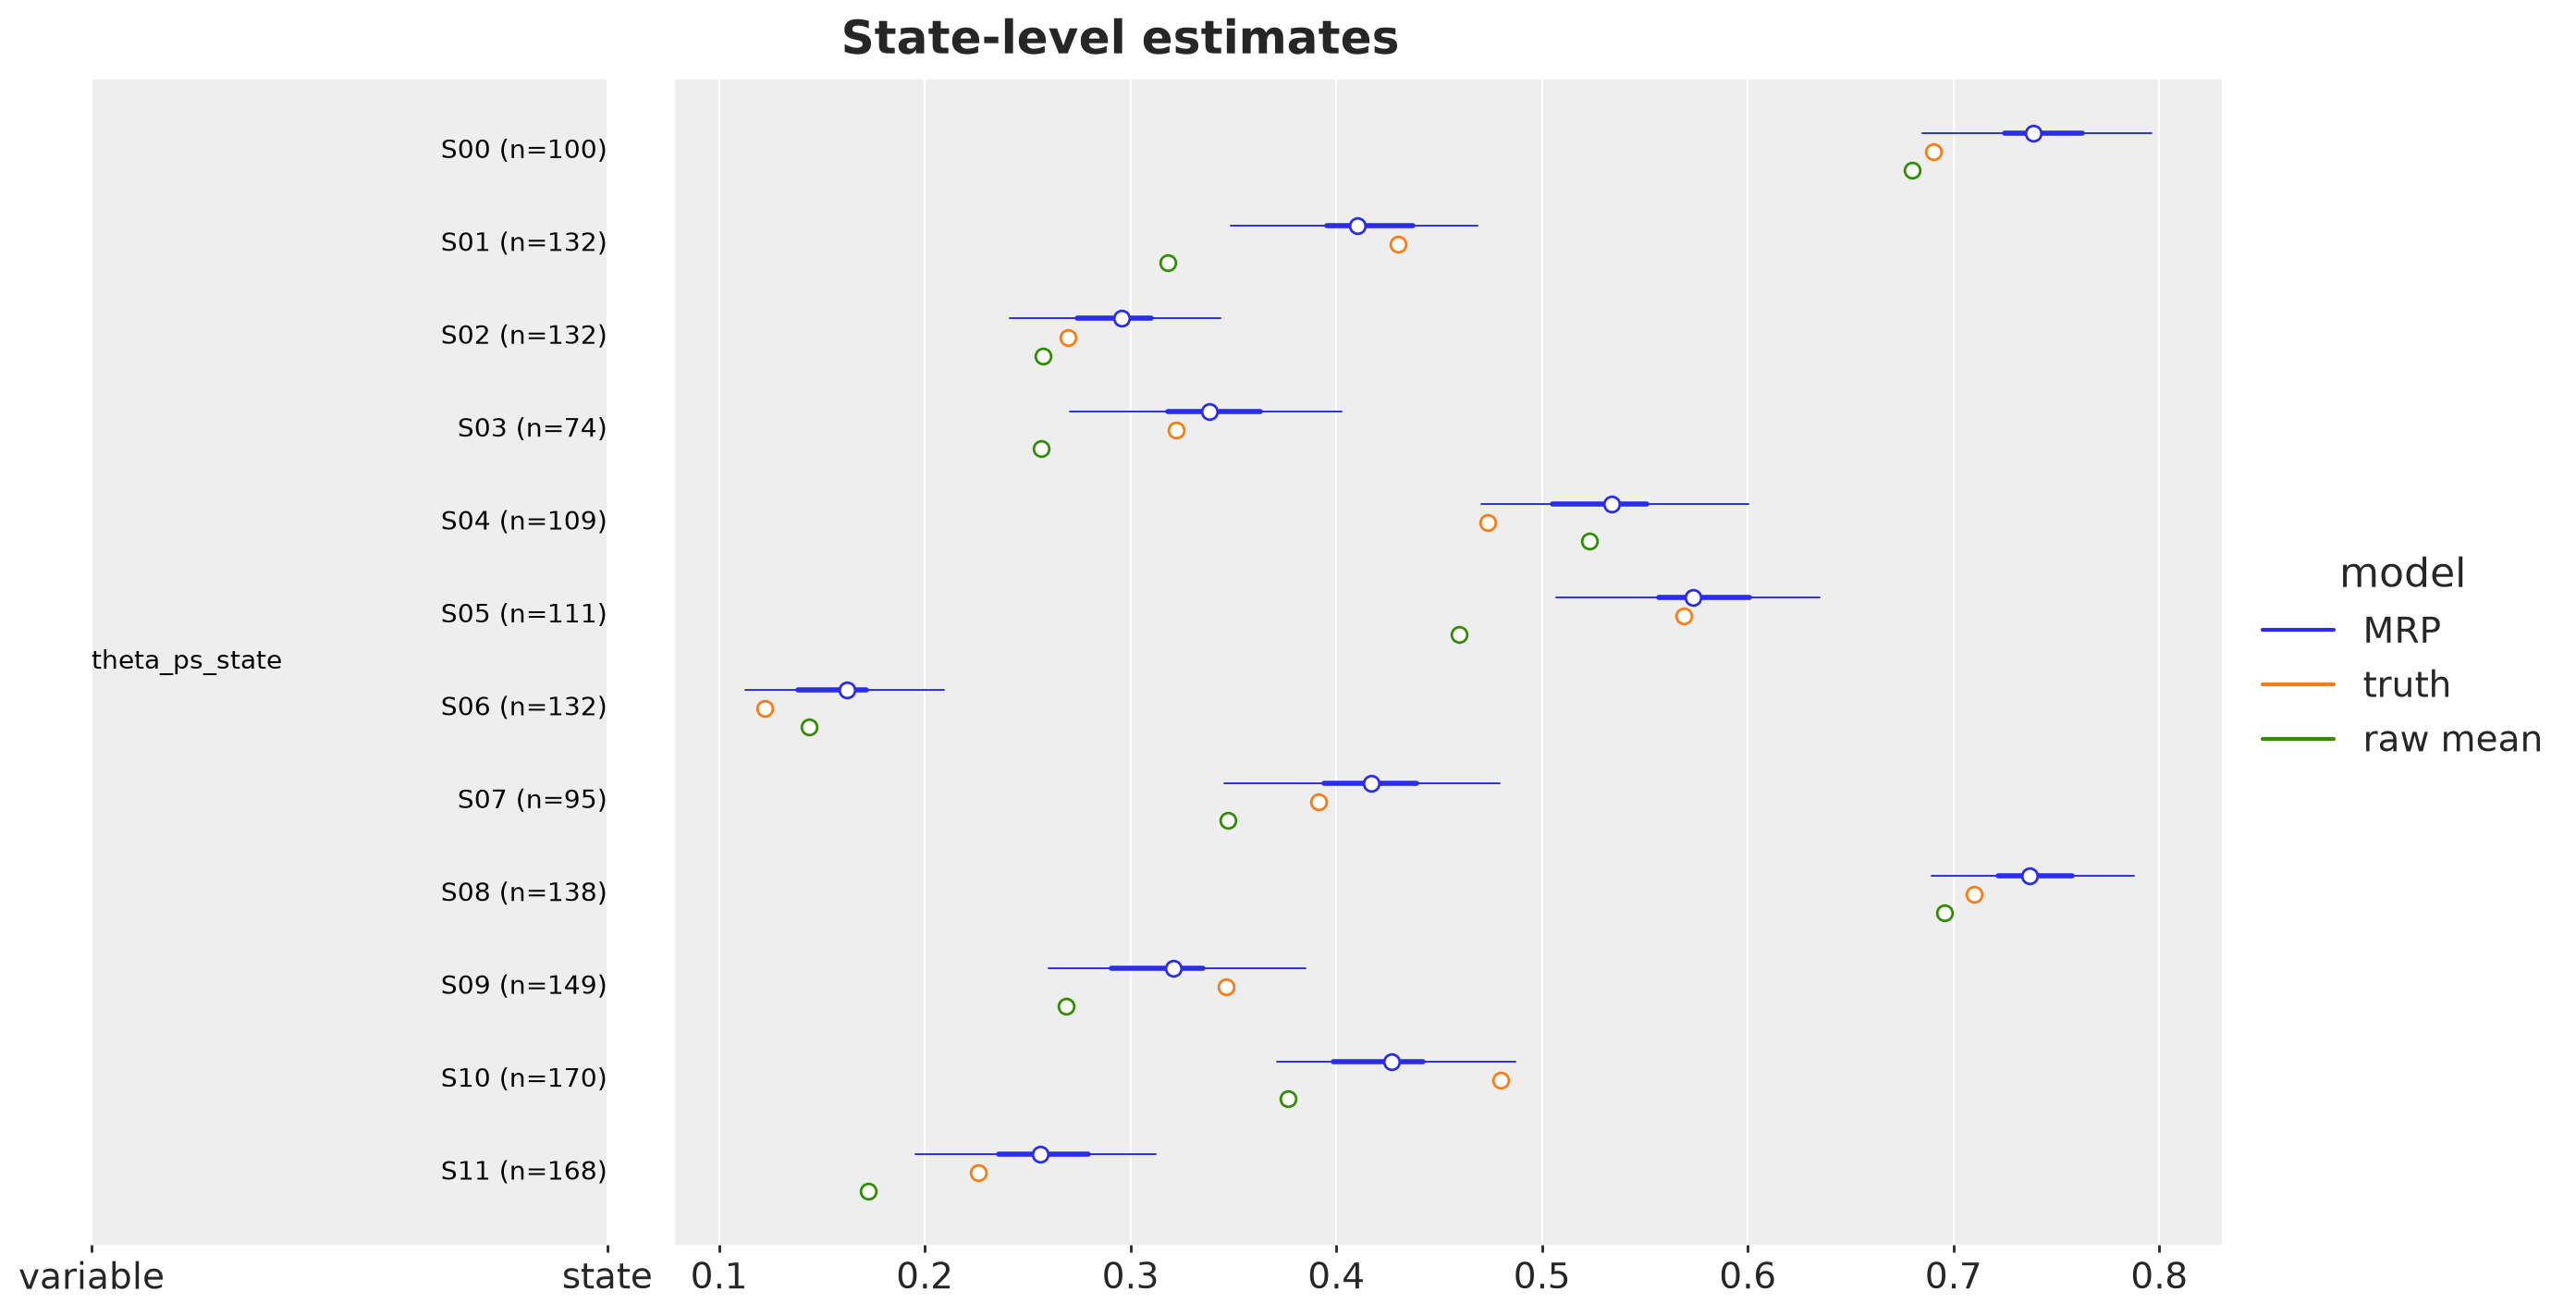

In [20]:
n_state = n_cell.sum(axis=(0, 1))
y_state = y_cell.sum(axis=(0, 1))
raw_mean_state = np.divide(
    y_state, n_state, out=np.full(n_state.shape, np.nan), where=n_state > 0
)

state_labels = [f"{state} (n={n})" for state, n in zip(states, n_state, strict=True)]


posterior_shape = (
    idata["posterior"].sizes["chain"],
    idata["posterior"].sizes["draw"],
    len(states),
)


def as_state_datatree(
    values: np.ndarray, var_name: str = "theta_ps_state"
) -> xr.DataTree:
    """Wrap state-level values as a posterior group with dimensions (chain, draw, state)."""  # noqa: E501
    return az.from_dict(
        {"posterior": {var_name: np.broadcast_to(values, posterior_shape)}},
        dims={var_name: ["state"]},
        coords={"state": state_labels},
    )


comparison = {
    "MRP": as_state_datatree(idata["posterior"]["theta_ps_state"].to_numpy()),
    "truth": as_state_datatree(theta_ps_state_true),
    "raw mean": as_state_datatree(raw_mean_state),
}

pc = az.plot_forest(
    comparison,
    var_names=["theta_ps_state"],
    combined=True,
    figure_kwargs={"figsize": (12, 7)},
)
pc.add_legend("model", title_fontsize=16, loc="center left", bbox_to_anchor=(1, 0.5))
pc.viz["figure"].item().suptitle(
    "State-level estimates", fontsize=18, fontweight="bold"
);

## Retargeting: Fit Once, Poststratify Many Times

The conditional surface $\theta_j$ is a property of the world. The weights $N_j$ describe which population we care about. Because the counts are `pmd.Data`, we can swap them and recompute the deterministic nodes for every posterior draw without sampling again. This is the transport formula of the g-formula section, with the new counts in the role of $\text{P}^*(X)$.

As an example we take a hypothetical population with a much older age structure.

In [21]:
age_multiplier = np.array([0.5, 0.8, 1.3, 2.0])
N_target = N_cell * age_multiplier[:, None, None]
theta_ps_target_true = np.average(theta_true, weights=N_target)

with mrp_model:
    pm.set_data({"N": N_target.astype(float)})
    posterior_target = pm.compute_deterministics(
        idata["posterior"].to_dataset(),
        var_names=["theta_ps", "theta_ps_state"],
        merge_dataset=False,
        progressbar=False,
    )
    pm.set_data({"N": N_cell.astype(float)})

We summarize the posterior of $\theta^{\text{PS}}$ under both sets of counts and compare it with the true value of each population.

In [22]:
posteriors = {
    "original population": idata["posterior"].to_dataset(),
    "older population": posterior_target,
}
truths = {
    "original population": theta_ps_true,
    "older population": theta_ps_target_true,
}

rows = []
for name, posterior in posteriors.items():
    hdi = az.hdi(posterior, var_names=["theta_ps"], prob=HDI_PROB)["theta_ps"]
    rows.append(
        {
            "population": name,
            "mrp_mean": posterior["theta_ps"].mean().item(),
            "hdi_lower": hdi.sel(ci_bound="lower").item(),
            "hdi_upper": hdi.sel(ci_bound="upper").item(),
            "truth": truths[name],
        }
    )

retargeting = pl.DataFrame(rows)

retargeting

population,mrp_mean,hdi_lower,hdi_upper,truth
str,f64,f64,f64,f64
"""original population""",0.430068,0.401549,0.454983,0.417201
"""older population""",0.492859,0.455493,0.528725,0.474067


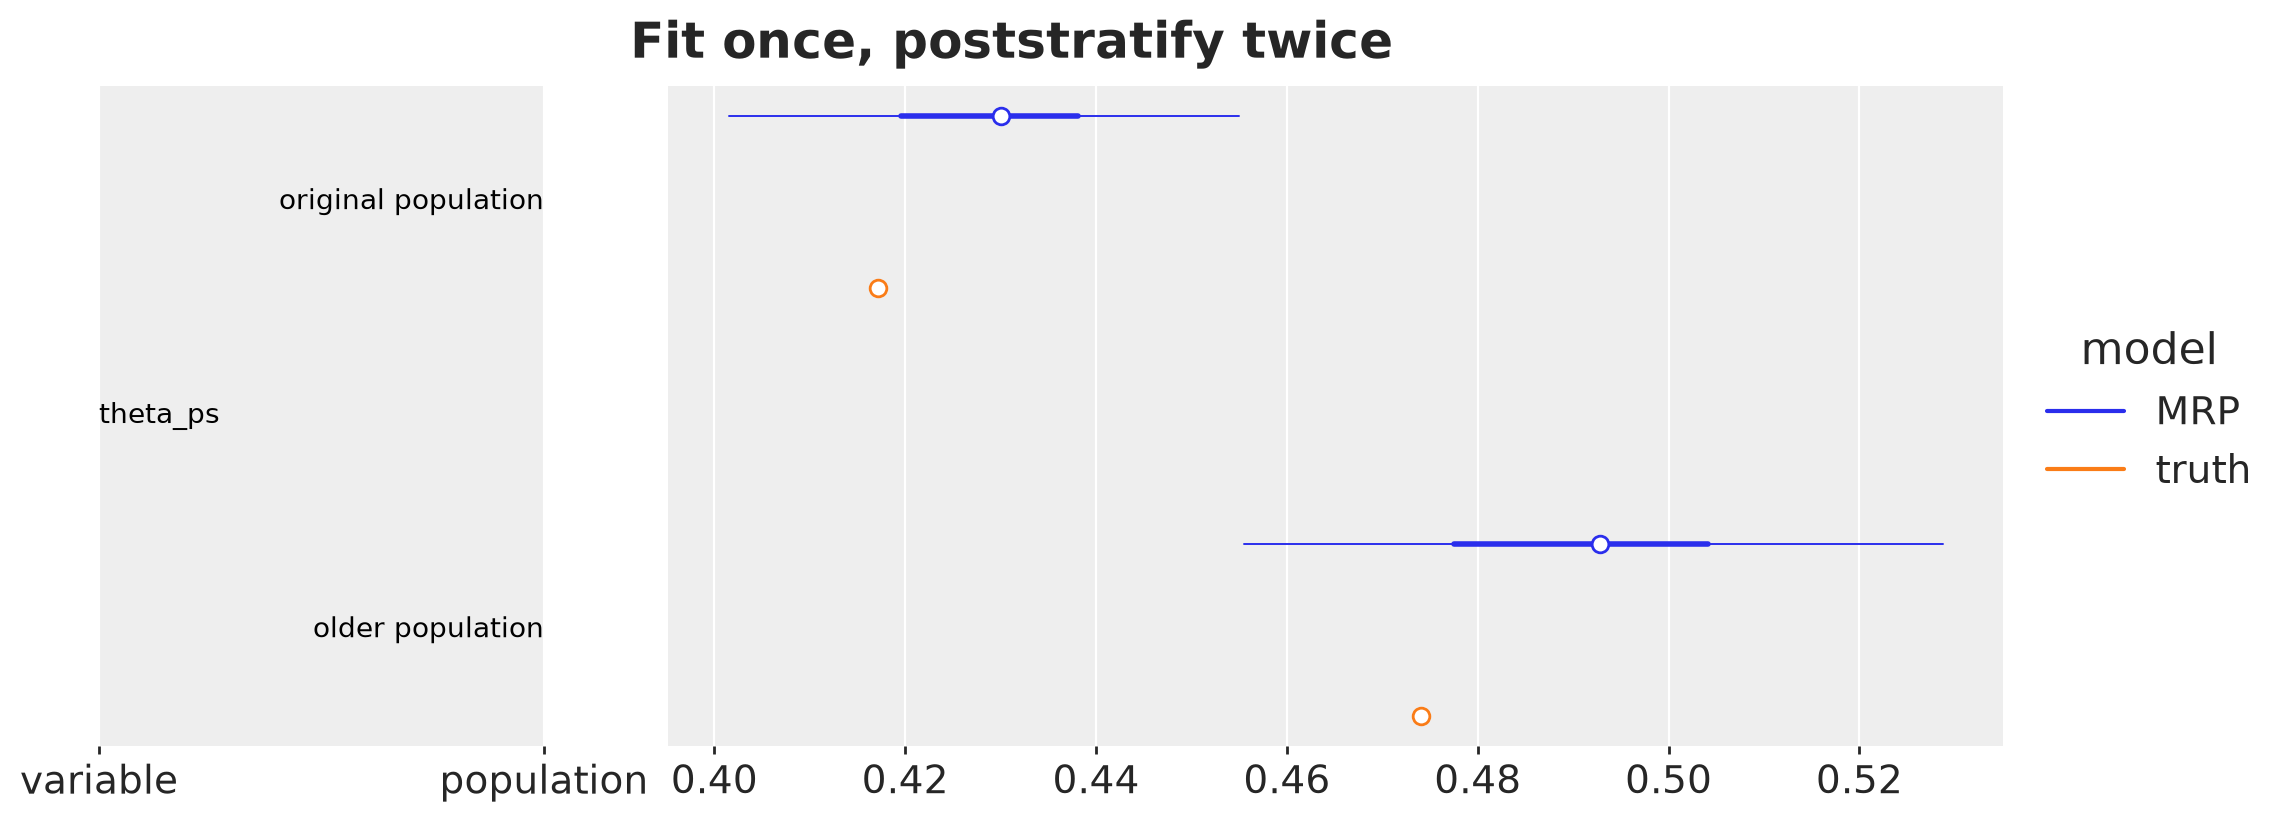

In [23]:
population_labels = list(posteriors)
theta_ps_populations = np.stack(
    [posterior["theta_ps"].to_numpy() for posterior in posteriors.values()], axis=-1
)
population_shape = (*theta_ps_populations.shape[:2], len(population_labels))


def as_population_datatree(values: np.ndarray) -> xr.DataTree:
    """Wrap population-level values as a posterior group with dimensions (chain, draw, population)."""  # noqa: E501
    return az.from_dict(
        {"posterior": {"theta_ps": np.broadcast_to(values, population_shape)}},
        dims={"theta_ps": ["population"]},
        coords={"population": population_labels},
    )


comparison_populations = {
    "MRP": as_population_datatree(theta_ps_populations),
    "truth": as_population_datatree(np.array(list(truths.values()))),
}

pc = az.plot_forest(
    comparison_populations,
    var_names=["theta_ps"],
    combined=True,
    figure_kwargs={"figsize": (10, 4)},
)
pc.add_legend("model", title_fontsize=16, loc="center left", bbox_to_anchor=(1, 0.5))
pc.viz["figure"].item().suptitle(
    "Fit once, poststratify twice", fontsize=18, fontweight="bold"
);

The older population leans more toward "yes", because the older age groups have the larger effects. In both cases the HDI covers the true value. The counts changed, the posterior draws did not.

## MRP in the Language of Marginal Effects

The [marginaleffects](https://marginaleffects.com/) package of [Arel-Bundock (2026)](https://marginaleffects.com/) organizes the interpretation of a fitted model around three quantities. A *prediction* is the expected outcome at one point of the covariate space. A *comparison* is the difference between two predictions that differ in one covariate. A *slope* is the derivative version of a comparison for a continuous covariate. The book [Model to Meaning](https://marginaleffects.com/) has a [chapter on MRP](https://marginaleffects.com/chapters/mrp.html) that reduces the method to one call: `avg_predictions(model, newdata=frame, wts="N", by="state")`. It predicts the outcome for every cell of the frame, averages the predictions with the census counts as weights, and groups the average by state. Step 2 of MRP is a weighted average of predictions, and the `by` argument gives the subpopulation estimates.

We can use the `datagrid` function to build the grids and we evaluate the posterior of $\theta_j$ on them ourselves, as we did for a Bambi model in [Ads, ROAS and Budgets](https://juanitorduz.github.io/ads_roas_interpret/). The posterior holds $\theta_j$ for every cell in the array `theta` with dimensions `age`, `eth` and `state`, so a prediction for a row of a grid is a lookup by label. We name the helpers after the marginaleffects functions they mimic.

### Predictions on a Grid

`datagrid` takes the frame and the values we want to vary. The covariates we do not name are held at their mode. We ask for the youngest and the oldest age group, two ethnicities, and the state with the fewest respondents.

In [24]:
def predict(theta: xr.DataArray, grid: pl.DataFrame) -> xr.DataArray:
    """Draws of theta for each row of the grid, stacked along a new dimension `row`."""
    indexers = {
        dim: xr.DataArray(grid[dim].to_numpy(), dims="row") for dim in frame_dims
    }
    return theta.sel(indexers)


state_small = states[int(np.argmin(n_state))]

profiles = datagrid(
    newdata=frame.select(frame_dims),
    age=["18-29", "65+"],
    eth=["white", "black"],
    state=state_small,
)

profiles

age,eth,state
str,str,str
"""18-29""","""white""","""S03"""
"""18-29""","""black""","""S03"""
"""65+""","""white""","""S03"""
"""65+""","""black""","""S03"""


For each row we get the posterior draws of $\theta_j$. The table shows the posterior mean, the HDI and the true value of each profile.

In [25]:
theta_profiles = predict(idata["posterior"]["theta"], profiles)

hdi_profiles = az.hdi(
    xr.Dataset({"theta": theta_profiles}), var_names=["theta"], prob=HDI_PROB
)["theta"]

profiles.with_columns(
    mrp_mean=theta_profiles.mean(("chain", "draw")).to_numpy(),
    hdi_lower=hdi_profiles.sel(ci_bound="lower").to_numpy(),
    hdi_upper=hdi_profiles.sel(ci_bound="upper").to_numpy(),
    theta_true=predict(world["theta"], profiles).to_numpy(),
)

age,eth,state,mrp_mean,hdi_lower,hdi_upper,theta_true
str,str,str,f64,f64,f64,f64
"""18-29""","""white""","""S03""",0.24663,0.172888,0.322998,0.260268
"""18-29""","""black""","""S03""",0.058057,0.033733,0.083578,0.060394
"""65+""","""white""","""S03""",0.67261,0.563906,0.786543,0.658231
"""65+""","""black""","""S03""",0.282139,0.178468,0.390323,0.260268


### Poststratification Is an Average Prediction

The `wts` argument weights the rows of the grid and the `by` argument groups the average. With the frame as the grid and the census counts as weights we recover both deterministic nodes of the model. With the counts of the older population we recover the retargeted estimate. The checks below compare the draws one by one.

In [26]:
def avg_predictions(
    theta: xr.DataArray, grid: pl.DataFrame, wts: str, by: str | None = None
) -> xr.DataArray:
    """Weighted average of the predictions over the rows of the grid, optionally by group."""  # noqa: E501
    pred = predict(theta, grid)
    w = xr.DataArray(grid[wts].to_numpy(), dims="row")
    if by is None:
        return (pred * w).sum("row") / w.sum("row")
    groups = xr.DataArray(grid[by].to_numpy(), dims="row", name=by)
    return (pred * w).groupby(groups).sum("row") / w.groupby(groups).sum("row")


theta_draws = idata["posterior"]["theta"]
frame_target = frame.with_columns(N_target=N_target.ravel())

checks = {
    "theta_ps": (
        avg_predictions(theta_draws, frame, wts="N"),
        idata["posterior"]["theta_ps"],
    ),
    "theta_ps_state": (
        avg_predictions(theta_draws, frame, wts="N", by="state"),
        idata["posterior"]["theta_ps_state"],
    ),
    "theta_ps, older population": (
        avg_predictions(theta_draws, frame_target, wts="N_target"),
        posterior_target["theta_ps"],
    ),
}

for from_grid, from_model in checks.values():
    np.testing.assert_allclose(
        from_grid.transpose(*from_model.dims).to_numpy(), from_model.to_numpy()
    )

Hence, the results are the same.

### Comparisons on the Probability Scale

The model has an age effect $\alpha^{\text{age}}$ on the logit scale. But the question "how much larger is the share of yes among people aged 65+ than among people aged 18-29?" lives on the probability scale, and its answer depends on the other covariates through the inverse logit. With `grid_type="counterfactual"`, `datagrid` duplicates the frame once per age group and keeps the other columns, including the counts, at their values. We predict both copies, take the difference cell by cell, and average with the census counts, overall and by state. This is the arithmetic of the g-formula with two interventions on $X$. For age it is a descriptive contrast between two types of people, not a causal effect. All covariates are discrete, so there are no slopes to compute.

In [27]:
age_grid = datagrid(
    newdata=frame.select([*frame_dims, "N"]),
    age=["18-29", "65+"],
    grid_type="counterfactual",
)

age_grid.head()

eth,state,N,rowidcf,age
str,str,i64,i64,str
"""white""","""S00""",26698,0,"""18-29"""
"""white""","""S00""",26698,0,"""65+"""
"""white""","""S01""",68307,1,"""18-29"""
"""white""","""S01""",68307,1,"""65+"""
"""white""","""S02""",30479,2,"""18-29"""


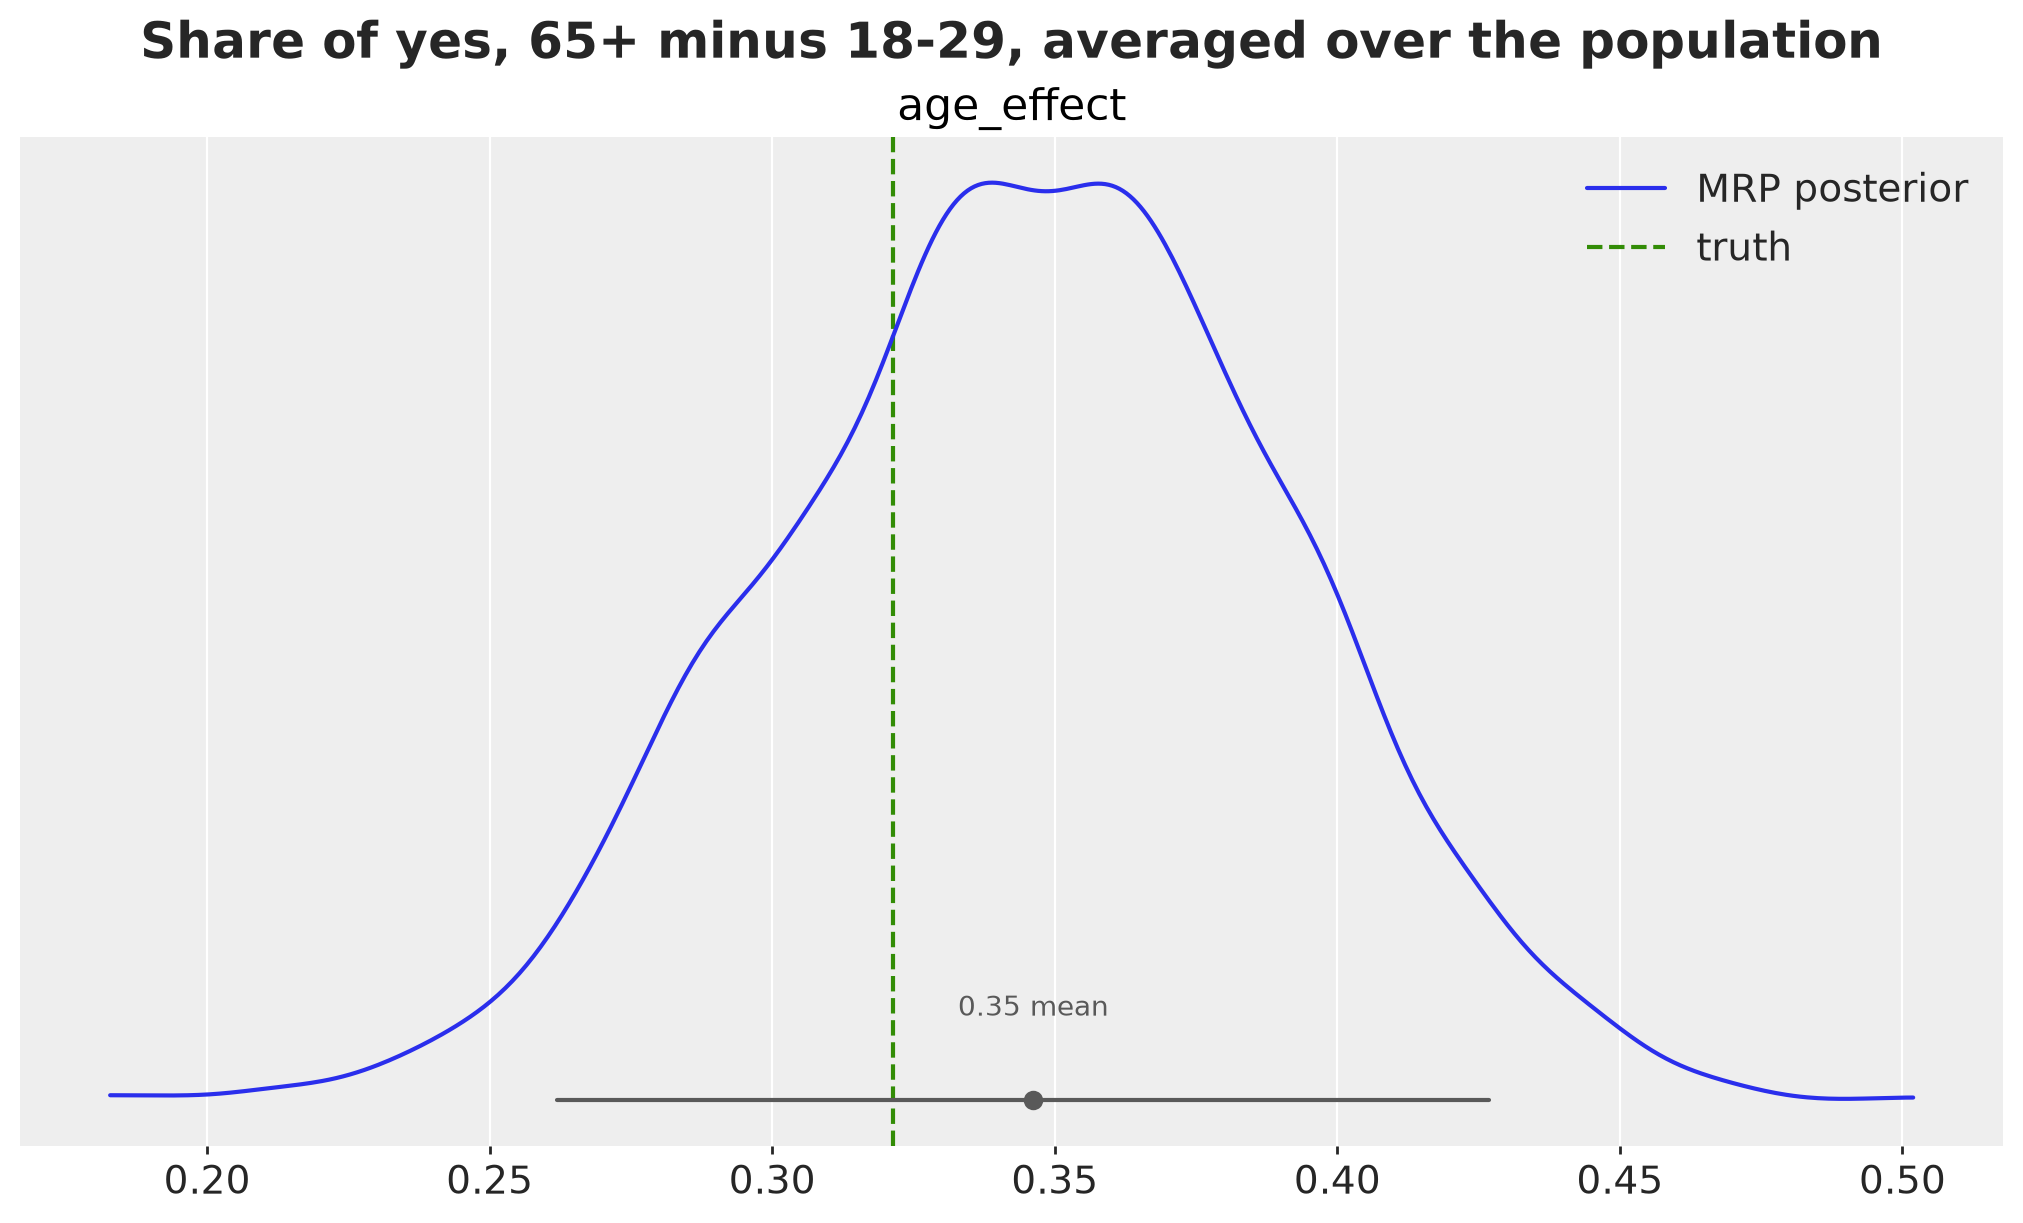

In [28]:
def avg_comparisons(
    theta: xr.DataArray,
    grid: pl.DataFrame,
    variable: str,
    values: tuple[str, str],
    wts: str,
    by: str | None = None,
) -> xr.DataArray:
    """Weighted average of the difference in predictions between two values of one variable."""  # noqa: E501
    lo, hi = values
    grid_lo = grid.filter(pl.col(variable).eq(lo)).sort("rowidcf")
    grid_hi = grid.filter(pl.col(variable).eq(hi)).sort("rowidcf")
    diff = predict(theta, grid_hi) - predict(theta, grid_lo)
    w = xr.DataArray(grid_lo[wts].to_numpy(), dims="row")
    if by is None:
        return (diff * w).sum("row") / w.sum("row")
    groups = xr.DataArray(grid_lo[by].to_numpy(), dims="row", name=by)
    return (diff * w).groupby(groups).sum("row") / w.groupby(groups).sum("row")


age_values = ("18-29", "65+")

age_effect = avg_comparisons(theta_draws, age_grid, "age", age_values, wts="N")
age_effect_true = avg_comparisons(
    world["theta"], age_grid, "age", age_values, wts="N"
).item()

pc = az.plot_dist(
    xr.Dataset({"age_effect": age_effect}),
    var_names=["age_effect"],
    figure_kwargs={"figsize": (10, 6)},
)
az.add_lines(
    pc,
    values={"age_effect": age_effect_true},
    visuals={"ref_line": {"color": "C2", "label": "truth"}},
)
pc.viz["dist"]["age_effect"].item().set_label("MRP posterior")
pc.get_target("age_effect", {}).legend(loc="upper right")
pc.viz["figure"].item().suptitle(
    "Share of yes, 65+ minus 18-29, averaged over the population",
    fontsize=18,
    fontweight="bold",
);

The state-level version of the same contrast uses `by="state"`. We compare it with the true contrast of each state.

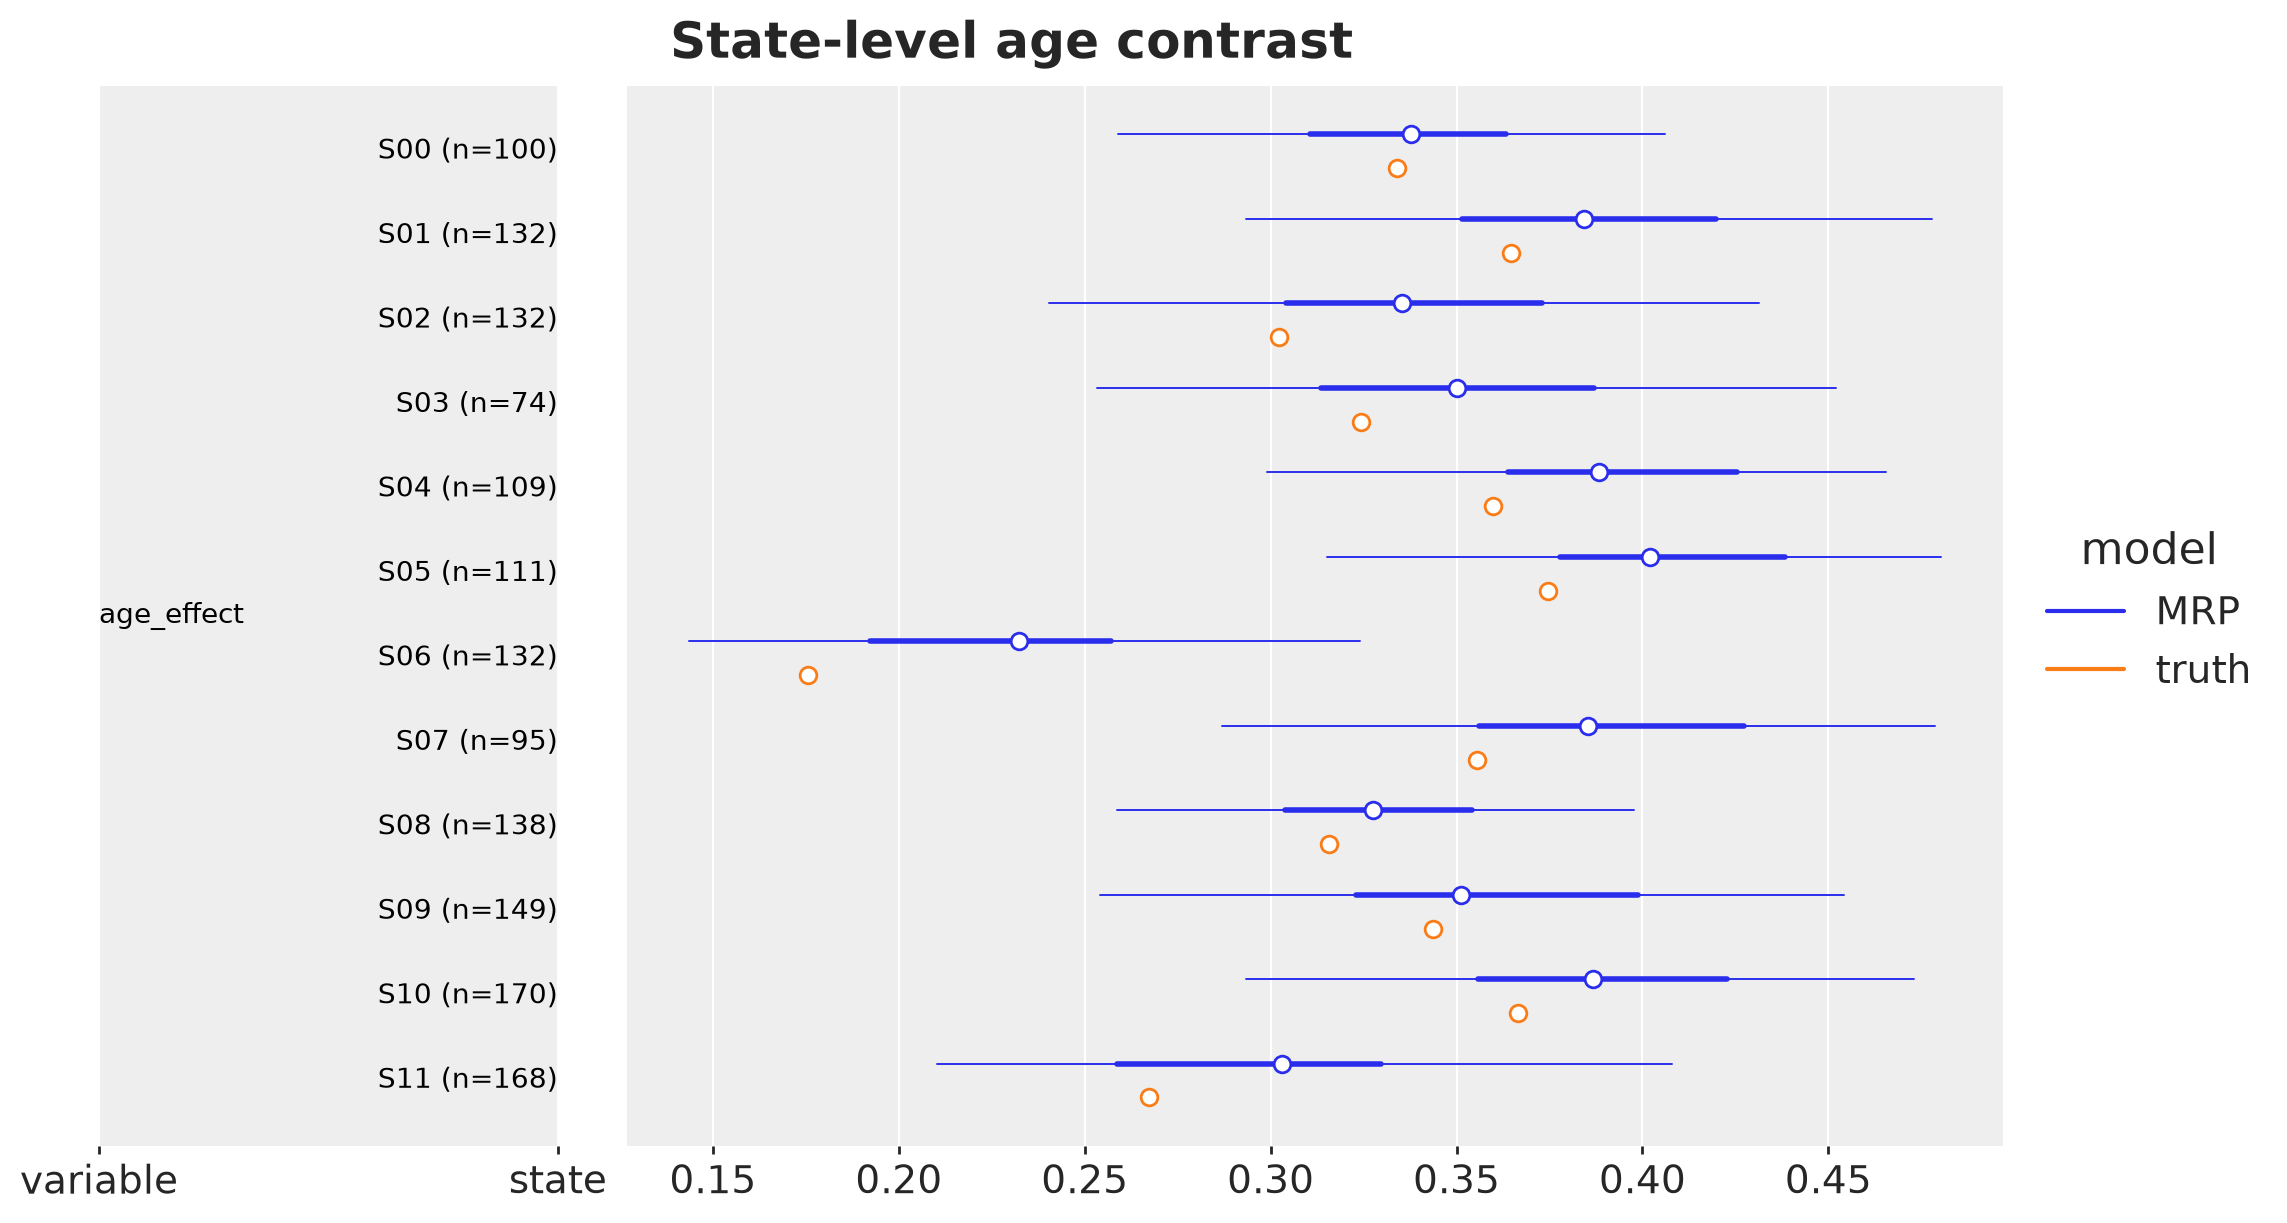

In [29]:
age_effect_state = avg_comparisons(
    theta_draws, age_grid, "age", age_values, wts="N", by="state"
)
age_effect_state_true = avg_comparisons(
    world["theta"], age_grid, "age", age_values, wts="N", by="state"
)

comparison_age = {
    "MRP": as_state_datatree(
        age_effect_state.transpose("chain", "draw", "state").to_numpy(),
        var_name="age_effect",
    ),
    "truth": as_state_datatree(age_effect_state_true.to_numpy(), var_name="age_effect"),
}

pc = az.plot_forest(
    comparison_age,
    var_names=["age_effect"],
    combined=True,
    figure_kwargs={"figsize": (10, 6)},
)
pc.add_legend("model", title_fontsize=16, loc="center left", bbox_to_anchor=(1, 0.5))
pc.viz["figure"].item().suptitle(
    "State-level age contrast", fontsize=18, fontweight="bold"
);

The posterior of the population-averaged contrast covers the true value. The state-level contrasts differ although the age effect on the logit scale is the same in every state: a state with a low share of "yes", such as S06, has a small contrast on the probability scale, and a state with a share near one half has a large one. This is the reason to report comparisons on the outcome scale and not coefficients. The intervals cover the true contrast of every state.

## Breaking the Assumption on Purpose

We now add the arrow $Y \to I$ of the first failure mode. We keep the world fixed, the same census, the same state effects and the same true probabilities, and we change only the response mechanism: with `response_ratio=3.0` a person who would answer "yes" is three times more likely to respond than a person who would answer "no", inside every cell. The MRP model is unchanged.

In [30]:
generative_model_bad = pm.do(
    make_generative_model(response_ratio=3.0),
    {
        **true_values,
        "N": N_cell.astype(float),
        "v": v_state,
        "b_state": world["b_state"].to_numpy(),
    },
)

with generative_model_bad:
    simulation_bad = pm.sample_prior_predictive(draws=1, random_seed=rng)

world_bad = simulation_bad["prior"].to_dataset().sel(chain=0, draw=0)

mrp_model_bad = make_mrp_model(
    N=N_cell,
    v=v_state,
    n=world_bad["n"].to_numpy().astype(int),
    y=world_bad["n_yes"].to_numpy().astype(int),
)

with mrp_model_bad:
    idata_bad = pm.sample(
        draws=1_000,
        tune=1_000,
        chains=4,
        random_seed=rng,
        progressbar=False,
    )

Sampling: [n_no, n_yes]
NUTS[nutpie]: [a0, s_age, s_eth, s_state, a_age, a_eth, g1, z_state]


In [31]:
az.diagnose(idata_bad);

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


In [32]:
print(f"MRP under Y ⊥ I | X : {idata['posterior']['theta_ps'].mean().item():.4f}")
print(f"MRP with Y → I      : {idata_bad['posterior']['theta_ps'].mean().item():.4f}")
print(f"true value          : {theta_ps_true:.4f}")

MRP under Y ⊥ I | X : 0.4301
MRP with Y → I      : 0.6329
true value          : 0.4172


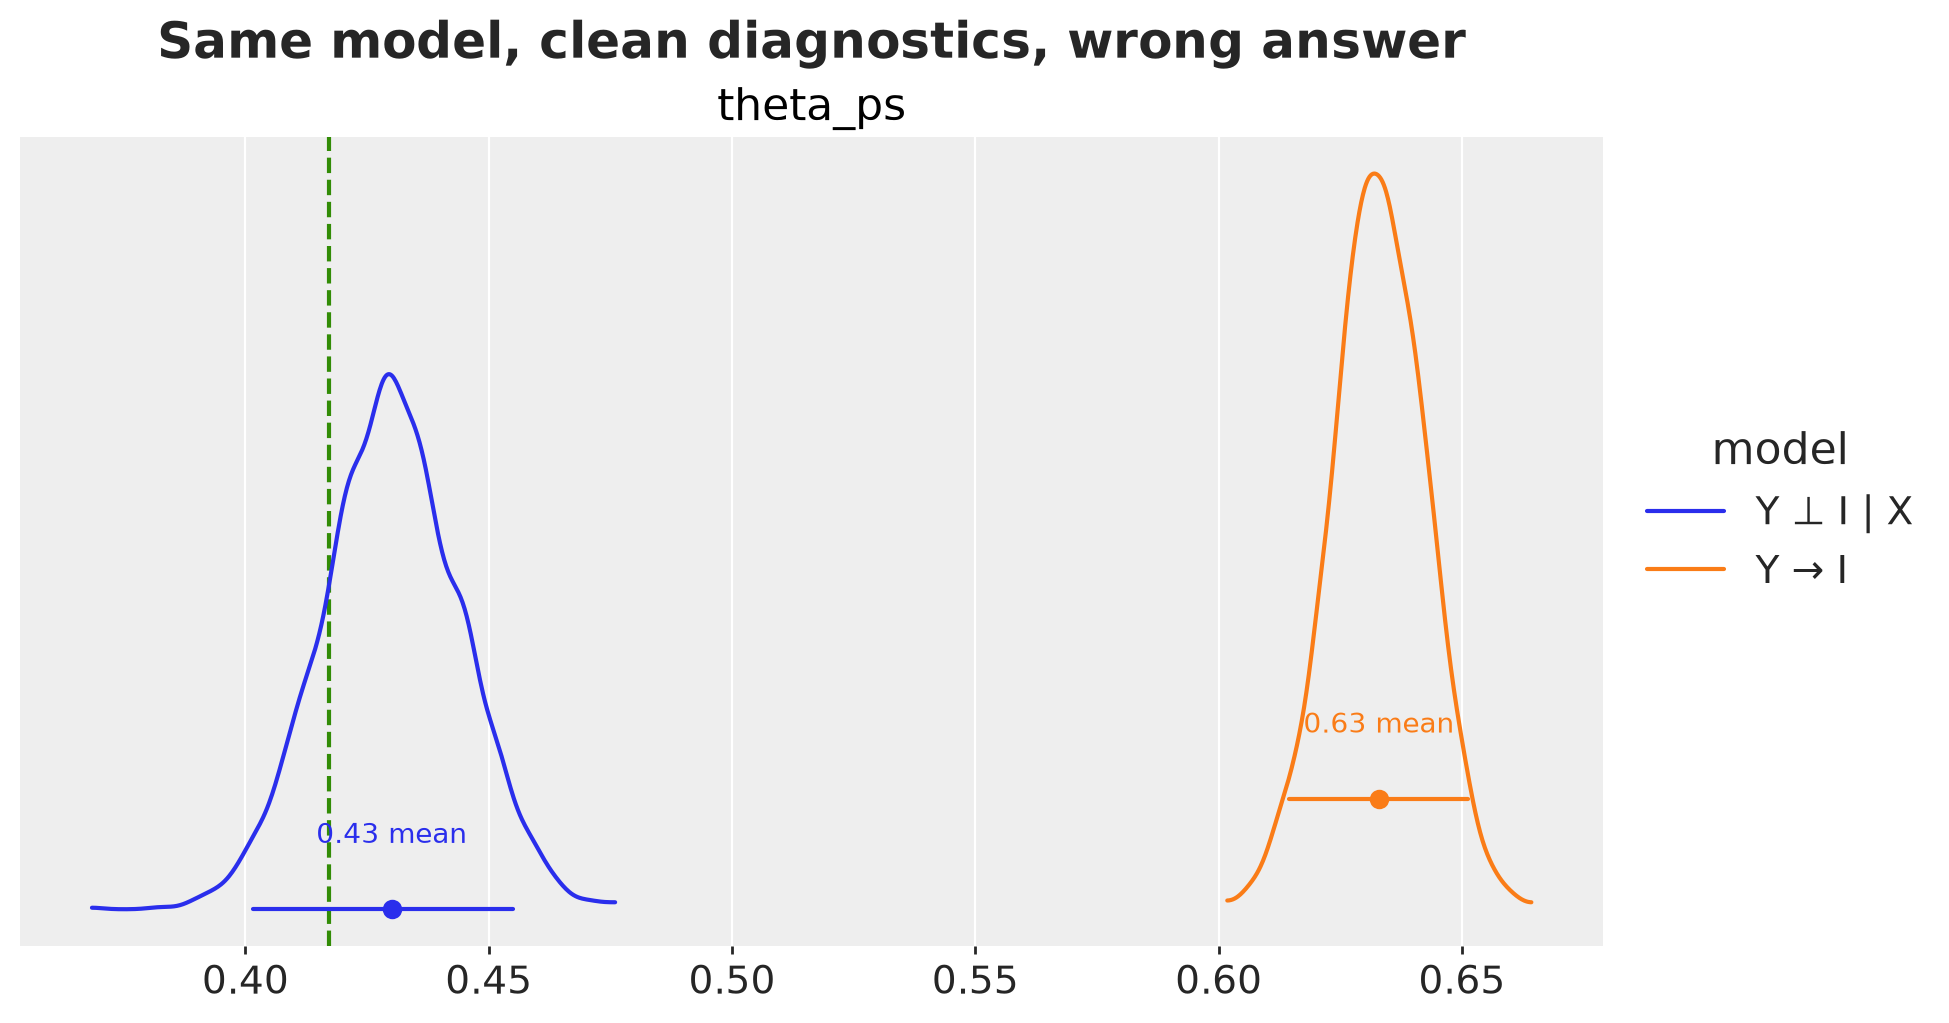

In [33]:
pc = az.plot_dist(
    {"Y ⊥ I | X": idata, "Y → I": idata_bad},
    var_names=["theta_ps"],
    figure_kwargs={"figsize": (8, 5)},
)
az.add_lines(
    pc,
    values={"theta_ps": theta_ps_true},
    visuals={"ref_line": {"color": "C2", "label": "truth"}},
)
pc.add_legend("model", title_fontsize=16, loc="center left", bbox_to_anchor=(1, 0.5))
pc.viz["figure"].item().suptitle(
    "Same model, clean diagnostics, wrong answer", fontsize=18, fontweight="bold"
);

The diagnostics are clean and the intervals are tight. The answer is wrong. Identification is an assumption about the world, not something the sampler can check for us.

## Applications in Marketing and Experimentation

MRP is usually presented as a polling method, but the two-step structure appears whenever the measured group differs from the group we care about. Marketing and experimentation are full of such cases. The table maps a few of them to the ingredients above: the cells of the frame, the outcome, and the main threat to $Y \perp I \mid X$.

| application | cells of the frame | outcome $Y$ | main threat |
|---|---|---|---|
| brand awareness or NPS survey sent to customers | segment x region x tenure, counted from the CRM | awareness, promoter status | unhappy customers answer more often ($Y \to I$) |
| online panel used as a market study | age x gender x region, counted from the census | purchase intent, category usage | panel members differ in unmeasured ways ($U$) |
| demand or market share by region with sparse data | product x region, with a regional predictor such as last year's sales | share of category buyers | regions with few respondents |
| A/B test on a non-representative group of users | platform x country x tenure, counted from the user base | conversion under each arm | opt-in or single-platform participants ($U$) |
| heterogeneous treatment effects across many segments | treatment x segment | conversion, revenue | too few units per segment |
| geo experiment with a brand-lift survey | region x age x gender | ad recall | survey respondents differ from the region population |

A few remarks.

- In the customer survey the frame is not a census but the customer base, and it is known exactly. The regional predictor of the market-share case plays the role of $v_s$: it gives small regions something to shrink toward.
- In the A/B test the experiment estimates $\text{E}[Y \mid A = a, X = x, I = 1]$ for the participants. To report the effect for the whole user base we poststratify both arms with the counts of the user base and take the difference. This is the combined formula of the g-formula section, and the retargeting code above is the recipe: fit once, then swap the counts.
- For heterogeneous effects, a multilevel model with treatment-by-segment effects is the "MR" of MRP. It gives a regularized effect for every segment, including the small ones, and the poststratified aggregates give the effect for any mix of segments.
- In every case the identifying assumption has to be argued, not tested. If the reason to respond, to opt in, or to be exposed is related to the outcome within the cells, MRP returns a precise and wrong number, as in the previous section.

## Extensions

- **Interactions.** Age by ethnicity is often where the signal is. With `pymc.dims` we add `pmd.ZeroSumNormal("a_age_eth", sigma=s_age_eth, core_dims=("age", "eth"), dims=("age", "eth"))` to the linear predictor and broadcasting does the rest. Deep interactions are where structured priors help ([Gao, Kennedy, Simpson and Gelman, 2021](https://doi.org/10.1214/20-BA1223)): a plain hierarchical prior shrinks an interaction toward zero, a structured prior shrinks it toward the additive model.
- **Nonparametric surfaces.** Replace the linear predictor with BART ([`pymc-bart`](https://www.pymc.io/projects/bart/)) or a Gaussian process over the cells and keep the poststratification step unchanged.
- **Uncertain counts.** The frame is usually estimated too. A Dirichlet-multinomial prior on the cell shares propagates that uncertainty into $\theta^{\text{PS}}$.
- **Continuous outcomes.** Swap the Binomial for a Normal likelihood as in the remark above. The rest of the notebook does not change.

## Conclusion

MRP splits a hard question into two easier ones. A multilevel regression estimates how each type of person answers, and a census-weighted average turns those estimates into a population quantity. The identifying assumption is that, within the cells of the frame, responding carries no information about the answer. We drew it as a DAG, and we showed that the averaging step is the g-formula with the response indicator in the role of the treatment.

On the implementation side, `pymc.dims` made the model read like the math. The effects broadcast to the grid by name, the poststratified quantities are one-line reductions, and the census counts are data we can swap without refitting. In the language of marginal effects, poststratification is an average prediction over the frame with the census counts as weights, and the same grid machinery gives contrasts on the probability scale. The failure case is the part to remember. When the response depends on the answer, the model looks healthy and the estimate is wrong. Identification is an assumption about the world, and the sampler cannot check it for us.

## References

- Wang, W., Rothschild, D., Goel, S. and Gelman, A. (2015). [Forecasting elections with non-representative polls](https://sites.stat.columbia.edu/gelman/research/published/forecasting-with-nonrepresentative-polls.pdf). *International Journal of Forecasting*, 31(3), 980-991.
- Gao, Y., Kennedy, L., Simpson, D. and Gelman, A. (2021). [Improving multilevel regression and poststratification with structured priors](https://doi.org/10.1214/20-BA1223). *Bayesian Analysis*, 16(3), 719-744.
- Bareinboim, E., Tian, J. and Pearl, J. (2014). [Recovering from selection bias in causal and statistical inference](https://ftp.cs.ucla.edu/pub/stat_ser/r425.pdf). *Proceedings of the AAAI Conference on Artificial Intelligence*, 28(1), 2410-2416.
- Hernán, M. A. and Robins, J. M. (2020). [Causal Inference: What If](https://miguelhernan.org/whatifbook). Chapman & Hall/CRC. Chapter 13 covers standardization and the parametric g-formula.
- Gelman, A., Vehtari, A., McElreath, R. et al. (2026). [Bayesian Workflow](https://avehtari.github.io/Bayesian-Workflow/). Chapman & Hall/CRC.
- Arel-Bundock, V. (2026). [Model to Meaning: How to interpret statistical models in R and Python](https://marginaleffects.com/). CRC Press. Chapter 12 covers [MRP](https://marginaleffects.com/chapters/mrp.html).
- [Ads, ROAS and Budgets: Interpreting and Communicating Statistical Models](https://juanitorduz.github.io/ads_roas_interpret/), the earlier post where `datagrid` is used with a Bambi model.
- [Multilevel Regression and Post-stratification in Bambi](https://bambinos.github.io/bambi/notebooks/mister_p.html), Bambi documentation.
- [Introduction to Causal Inference with PPLs](https://juanitorduz.github.io/intro_causal_inference_ppl_pymc/), the earlier post where the g-formula is computed with `pm.do`.
- [The `dims` module](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/dims_module.html), PyMC documentation.
- [MMM data generator](https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_data_generator.html), PyMC-Marketing documentation.